# Practica 04: Analisis de Datos Exploratorios con Python y Jupiter Notebook en un Dataset de Productos de Amazon Store

**Programa  de Estudios:** Ingenieria en Entornos Virtuales y Negocios Digitales \
**Asignatura:** Analítica de Datos para Negocios Digitales \
**Docente:** M.T.I. Marco A. Ramírez Hernández \
**Periodo:** Mayo - Agosto 2026


### Unidad 2: Preparación de los Datos

**Nombre del Estudiante:** Adriana Rosales Gayosso \
**Matricula:** 230671 \
**Grado y Grupo:** 9°A IEVND

<div style="background: linear-gradient(135deg, #D4EDDA 0%, #E6E6FA 100%); padding: 30px; border-radius: 15px; text-align: center; margin-bottom: 20px;">

<h1 style="color: #E0F7FA; font-size: 2.2em; margin: 0;">
🛒 Productos de Amazon Store - Análisis Exploratorio de Datos Completo & Aprendizaje Automático Predictivo (ML)
</h1>

<p style="color: #DB7093; font-size: 1.1em; margin-top: 10px;">
Predicción de Precios · Análisis de Categorías · Ingeniería de Funcionalidades · Comparación de Modelos
</p>

</div>

## Tabla de Contenidos
| # | Sección | Descripción |
|---|---|---|
| 1 | [Instalaciones & Carga de Datos](#1) | Librerías, carga del CSV y primeros comandos de visualización rápida. |
| 2 | [Diccionario de Datos](#2) | Explicación del contenido de columnas y cálculo del % de datos faltantes. |
| 3 | [Limpieza de Datos](#3) | Aplicación de métodos básicos de limpieza (eliminación de duplicados, formateo y manejo de nulos). |
| 4 | [Ingeniería de Características](#4) | Creación de nuevas variables (transformación logarítmica, longitud de texto y disponibilidad). |
| 5 | [Análisis Estadístico Descriptivo](#5) | Resumen estadístico, medidas de tendencia central y dispersión de las variables. |
| 6 | [Visualización de Datos Univariada](#6) | Gráficos de distribución de frecuencias para precios y variables clave. |
| 7 | [Análisis Bivariado y Multivariado](#7) | Matriz de correlación de variables numéricas y mapas de calor. |
| 8 | [Planteamiento de Hipótesis](#8) | Definición formal de las cuatro hipótesis estadísticas del proyecto de negocio. |
| 9 | [Pruebas de Hipótesis Estadísticas](#9) | Aplicación de pruebas (Kruskal-Wallis, Mann-Whitney U y Spearman) y análisis de p-valores. |
| 10 | [Preprocesamiento para Machine Learning](#10) | Selección de características, definición de la variable objetivo y codificación One-Hot. |
| 11 | [División del Dataset](#11) | Segmentación de los datos en conjuntos de entrenamiento y prueba (Train/Test Split). |
| 12 | [Modelado de Regresión](#12) | Configuración y entrenamiento de múltiples algoritmos predictivos. |
| 13 | [Evaluación de Modelos](#13) | Pipeline de evaluación y comparación de rendimiento con métricas ($R^2$ y MAE). |
| 14 | [Interpretación de Resultados y Moneda](#14) | Conversión inversa del error logarítmico para obtener la desviación real en Rupias (₹). |
| 15 | [Conclusiones del Negocio Digital](#15) | Hallazgos predictivos finales y recomendaciones comerciales para Amazon. |

## 1. Instalaciones & Carga de Datos <a id='s1'></a>
<div style="background:#f0f8ff; padding:12px; border-left:4px solid #FF9900; border-radius:5px 0 0 5px; color:#0066cc;">
<b>Dataset:</b> Amazon India Listas de Productos – 1,436 productos entre Libros, Kindle, Deportes & más<br>
<b>Objetivo:</b> Predecir el precio del producto (INR) desde la categoría, longitud del nombre, y disponibilidad<br>
<b>DataSource:</b> Web-scraped de páginas de productos Amazon.in
</div>

In [80]:
# ============================================================
# SECTION 1 — Setup & Data Loading
# ============================================================
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
from scipy import stats
from scipy.stats import shapiro, kruskal, spearmanr, mannwhitneyu, f_oneway

# ML
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline

try:
    import xgboost as xgb
    XGB_AVAILABLE = True
except ImportError:
    XGB_AVAILABLE = False

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

print(f'✅ Pandas  : {pd.__version__}')
print(f'✅ NumPy   : {np.__version__}')
print(f'✅ XGBoost : {XGB_AVAILABLE}')
print('✅ All libraries loaded!')


✅ Pandas  : 2.0.3
✅ NumPy   : 1.24.3
✅ XGBoost : False
✅ All libraries loaded!


In [81]:
# Load dataset

df_raw = pd.read_csv('./amazon_products_data.csv', encoding='latin-1')

print(f' Shape   : {df_raw.shape}')
print(f' Columns : {df_raw.columns.tolist()}')

df_raw.head(3)

 Shape   : (1455, 17)
 Columns : ['rl', 'asin', 'name', 'overview', 'price', 'currency', 'availability', 'brand', 'about_item', 'img_source', 'description', 'specifications', 'primary_category', 'category_1', 'category_2', 'category_3', 'breadcrumbs']


,rl,asin,name,overview,price,currency,availability,brand,about_item,img_source,description,specifications,primary_category,category_1,category_2,category_3,breadcrumbs
0,https://www.amazon.in/dp/1788832566,1788832566,Hands-On Design Patterns with C++: Solve commo...,[],"1,600.00",INR,NaN,by \r\n Fedor G. Pikus (...,NaN,https://images-na.ssl-images-amazon.com/images...,NaN,[],Books,Computers & Internet,Programming & Software Development,NaN,Books | Computers & Internet | Programming & S...
1,https://www.amazon.in/dp/0766199592,0766199592,The Blazing Horizon The True Story of Pawnee B...,[],"2,399.00",INR,Usually dispatched in 13 to 14 days.,by \r\nErnest Lynn \r\n(Author),NaN,https://images-na.ssl-images-amazon.com/images...,NaN,[],Books,Action & Adventure,NaN,NaN,Books | Action & Adventure
2,https://www.amazon.in/dp/B071ZCD9XH,B071ZCD9XH,Fast and easy lunch box: A collection of 15eas...,[],NaN,NaN,NaN,by \r\nNinety Nine Cents Pr...,NaN,https://m.media-amazon.com/images/I/41g9Z21QuG...,NaN,[],Kindle Store,Kindle eBooks,"Crafts, Home & Lifestyle",NaN,"Kindle Store | Kindle eBooks | Crafts, Home & ..."


## 2. Diccionario de Datos del Data Frame.

In [82]:
# Column dictionary
col_info = {
    'rl': 'URL del Producto en Amazon.in',
    'asin': 'Número Estandarizado de Identificación por Amazon (unique ID)',
    'name': 'Nombre o Título del Producto',
    'overview': 'Breve Reseña del Producto (mayoría vacío [])',
    'price': 'Precio como string (e.g. "1,600.00")',
    'currency': 'Código de Divisa (todas en INR)',
    'availability': 'Texto del Status del Stock (Inventario)',
    'brand': 'Nombre de la Marca/Autor ',
    'about_item': 'Detalles/Especificaciones (mayoría faltante)',
    'img_source': 'URLs de Imágenes del Producto',
    'description': 'Descripción detallada y completa (mayoría faltante)',
    'specifications': 'Especificaciones Técnicas',
    'primary_category': 'Categoría Principal (Libros, Kindle, Deportes ... )',
    'category_1': 'Subcategoría de nivel 1',
    'category_2': 'Subcategoría de nivel 2',
    'category_3': 'Subcategoría de nivel 3',
}
print('Diccionario por columnas:')
for col, desc in col_info.items():
    missing_pct = df_raw[col].isnull().mean() *100
    print(
        f' {col:20s} | '
        f'{desc[:45]:45s} | '
        f'Missing: {missing_pct:.0f}%'
)

Diccionario por columnas:
 rl                   | URL del Producto en Amazon.in                 | Missing: 0%
 asin                 | Número Estandarizado de Identificación por Am | Missing: 0%
 name                 | Nombre o Título del Producto                  | Missing: 0%
 overview             | Breve Reseña del Producto (mayoría vacío [])  | Missing: 0%
 price                | Precio como string (e.g. "1,600.00")          | Missing: 24%
 currency             | Código de Divisa (todas en INR)               | Missing: 24%
 availability         | Texto del Status del Stock (Inventario)       | Missing: 34%
 brand                | Nombre de la Marca/Autor                      | Missing: 1%
 about_item           | Detalles/Especificaciones (mayoría faltante)  | Missing: 92%
 img_source           | URLs de Imágenes del Producto                 | Missing: 1%
 description          | Descripción detallada y completa (mayoría fal | Missing: 92%
 specifications       | Especificaciones Técn

## 3. Limpieza de Datos

<div style="background:#fff8e1; padding:12px; border-left:4px solid #FF9900; border-radius:5px; color: #0066cc;">
<b>Pasos clave para la limpieza:</b><br>
• Parsear el precio strings como "1,600.00" -> float 1600.0<br>
• Manejar los datos faltantes (price: 24%, availability: 33%, description: 92%)<br>
• Estandarizar el texto de disponibilidad en categorías limpias<br>
• Eliminar duplicados
</div>

In [60]:
# ============================================================
# SECTION 2 — Data Cleaning
# ============================================================
df = df_raw.copy()

# ── Parse price ─────────────────────────────────────────────
def clean_price(p):
    if pd.isna(p): return np.nan
    p = str(p).replace(',', '').strip()
    m = re.search(r'[\d.]+', p)
    return float(m.group()) if m else np.nan

df['price_clean'] = df['price'].apply(clean_price)

# ── Standardise availability ─────────────────────────────────
def clean_availability(a):
    if pd.isna(a): return 'Unknown'
    a = str(a).strip().lower()
    if 'in stock' in a:          return 'In Stock'
    if 'unavailable' in a:       return 'Unavailable'
    if '1 to 3' in a:            return 'Ships 1-3 weeks'
    if '4 to 5' in a or '6 to' in a or '9 to' in a: return 'Ships 4-14 days'
    if '13 to 14' in a or '2 to 3 weeks' in a:      return 'Ships 2+ weeks'
    if 'only' in a and 'left' in a: return 'Low Stock'
    if '2 to 3 days' in a or '1 to 2 days' in a:    return 'Ships 1-3 days'
    return 'Other'

df['avail_clean'] = df['availability'].apply(clean_availability)

# ── Text length features ─────────────────────────────────────
df['name_length']  = df['name'].fillna('').str.len()
df['name_words']   = df['name'].fillna('').str.split().str.len()
df['has_brand']    = df['brand'].notna().astype(int)
df['has_desc']     = df['description'].notna().astype(int)
df['has_specs']    = df['specifications'].notna().astype(int)

# ── Duplicate check ──────────────────────────────────────────
dupes = df.duplicated(subset='asin').sum()
print(f'✅ Price parsed: {df["price_clean"].notna().sum():,} / {len(df):,} products')
print(f'✅ Duplicate ASINs: {dupes}')
print(f'✅ Availability categories: {df["avail_clean"].value_counts().to_dict()}')
df[['name','price_clean','avail_clean','primary_category','name_length']].head(5)

✅ Price parsed: 1,103 / 1,455 products
✅ Duplicate ASINs: 15
✅ Availability categories: {'In Stock': 607, 'Unknown': 493, 'Ships 1-3 weeks': 121, 'Ships 4-14 days': 115, 'Ships 2+ weeks': 80, 'Other': 23, 'Ships 1-3 days': 16}


,name,price_clean,avail_clean,primary_category,name_length
0,Hands-On Design Patterns with C++: Solve commo...,1600.0,Unknown,Books,118
1,The Blazing Horizon The True Story of Pawnee B...,2399.0,Ships 2+ weeks,Books,74
2,Fast and easy lunch box: A collection of 15eas...,NaN,Unknown,Kindle Store,108
3,European Foreign Policy Scorecard 2014,NaN,Unknown,Kindle Store,38
4,The 13th Hour: Chaos (Volume 2) (The Nick Quin...,1849.0,Ships 2+ weeks,Books,64


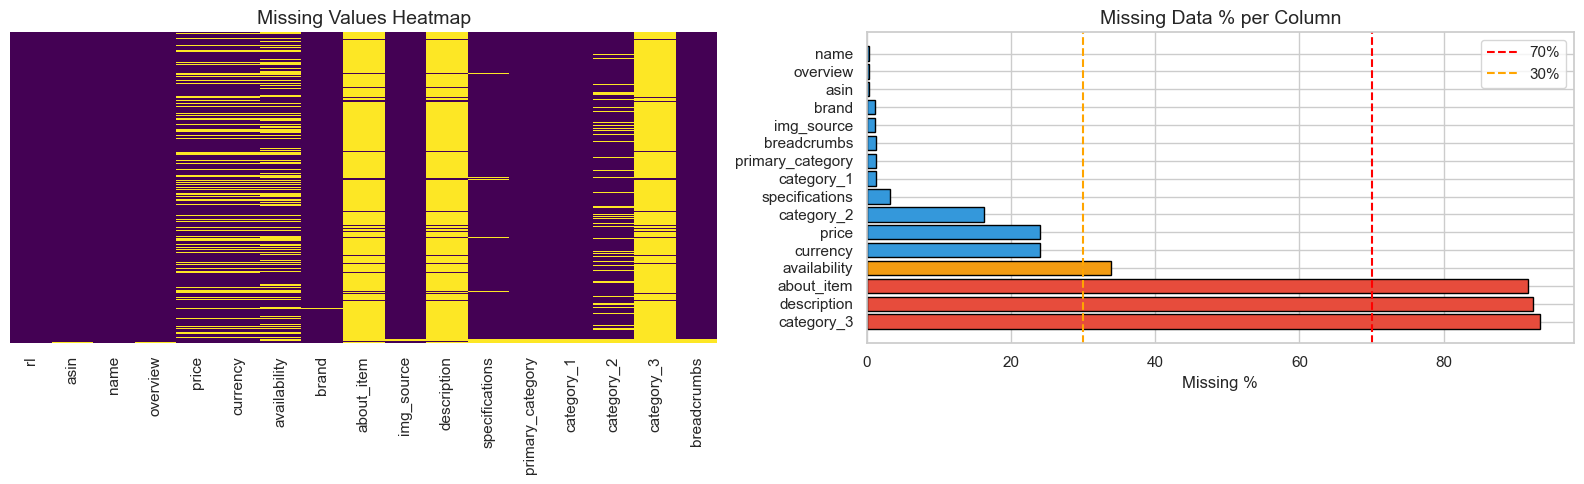

                  Missing Count  Missing Pct
category_3                 1359         93.4
description                1345         92.4
about_item                 1334         91.7
availability                493         33.9
currency                    350         24.1
price                       349         24.0
category_2                  237         16.3
specifications               48          3.3
category_1                   19          1.3
primary_category             19          1.3
breadcrumbs                  19          1.3
img_source                   16          1.1
brand                        16          1.1
asin                          6          0.4
overview                      6          0.4
name                          6          0.4


In [61]:
# Missing value summary
missing = pd.DataFrame({
    'Missing Count': df_raw.isnull().sum(),
    'Missing Pct': (df_raw.isnull().sum() / len(df_raw) * 100).round(1)
}).sort_values('Missing Pct', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Aquí corregí 'Viridis' por 'viridis' con minúscula
sns.heatmap(df_raw.isnull(), cbar=False, yticklabels=False,
            cmap='viridis', ax=axes[0])
axes[0].set_title('Missing Values Heatmap')

mv = missing[missing['Missing Pct'] > 0]
colors_mv = ['#e74c3c' if v > 70 else '#f39c12' if v > 30 else '#3498db'
             for v in mv['Missing Pct']]

# Dibujar barras solo si hay columnas con valores faltantes
if not mv.empty:
    axes[1].barh(mv.index, mv['Missing Pct'], color=colors_mv, edgecolor='black')
    axes[1].axvline(70, color='red', linestyle='--', label='70%')
    axes[1].axvline(30, color='orange', linestyle='--', label='30%')
    axes[1].set_xlabel('Missing %')
    axes[1].set_title('Missing Data % per Column')
    axes[1].legend()
else:
    axes[1].text(0.5, 0.5, 'No hay valores faltantes', 
                 horizontalalignment='center', verticalalignment='center')

plt.tight_layout()
plt.show()

print(missing[missing['Missing Count'] > 0].to_string())

## 4. Ingenieria de caracteristicas (Feature Engineering)

<div style="background:#f0fff0; padding:12px; border-left:4px solid #27ae60; border-radius:5px; color:#0066cc;">
    <b>Ejemplo Cotidiano:</b> Un agente inmobiliario no solo utiliza los metros cuadrados brutos, sino que también considera la ubicación, la antigüedad y el estado. Nosotros hacemos lo mismo: extraemos información más valiosa del texto sin procesar y las categorías.
</div>

In [62]:
# ============================================================
# SECTION 3 — Feature Engineering
# ============================================================

# ── Category flags ───────────────────────────────────────────
df['is_book']    = (df['primary_category'] == 'Books').astype(int)
df['is_kindle']  = (df['primary_category'] == 'Kindle Store').astype(int)
df['is_sports']  = (df['primary_category'].str.contains('Sport', na=False)).astype(int)

# ── Sub-category flags ───────────────────────────────────────
df['is_fiction']    = df['category_1'].fillna('').str.contains('Fiction|Adventure|Crime|Romance|Sci-Fi', case=False).astype(int)
df['is_nonfiction'] = df['category_1'].fillna('').str.contains('History|Politics|Business|Science|Education', case=False).astype(int)
df['is_tech']       = df['category_1'].fillna('').str.contains('Computer|Programming|Technology', case=False).astype(int)
df['is_cycling']    = df['category_1'].fillna('').str.contains('Cycling', case=False).astype(int)

# ── Availability flags ───────────────────────────────────────
df['is_instock']     = (df['avail_clean'] == 'In Stock').astype(int)
df['is_unavailable'] = (df['avail_clean'] == 'Unavailable').astype(int)
df['is_lowstock']    = (df['avail_clean'] == 'Low Stock').astype(int)

# ── Price features ───────────────────────────────────────────
df['log_price'] = np.log1p(df['price_clean'])

def price_tier(p):
    if pd.isna(p):  return 'Unknown'
    if p < 300:     return '1_budget'
    if p < 800:     return '2_low'
    if p < 1500:    return '3_mid'
    if p < 3000:    return '4_premium'
    return '5_luxury'

df['price_tier'] = df['price_clean'].apply(price_tier)

# ── Label encode primary category ───────────────────────────
le_cat = LabelEncoder()
df['primary_cat_enc'] = le_cat.fit_transform(df['primary_category'].fillna('Unknown'))

le_cat1 = LabelEncoder()
df['cat1_enc'] = le_cat1.fit_transform(df['category_1'].fillna('Unknown'))

le_avail = LabelEncoder()
df['avail_enc'] = le_avail.fit_transform(df['avail_clean'])

print(f'✅ Total de Funciones totales diseñadas : {len(df.columns)}')
print('\nDistribución por niveles de precios:')
print(df['price_tier'].value_counts().sort_index().to_string())
df[['name','price_clean','price_tier','primary_category','is_book','is_instock']].head(6)


✅ Total de Funciones totales diseñadas : 39

Distribución por niveles de precios:
price_tier
1_budget     105
2_low        285
3_mid        319
4_premium    268
5_luxury     126
Unknown      352


,name,price_clean,price_tier,primary_category,is_book,is_instock
0,Hands-On Design Patterns with C++: Solve commo...,1600.0,4_premium,Books,1,0
1,The Blazing Horizon The True Story of Pawnee B...,2399.0,4_premium,Books,1,0
2,Fast and easy lunch box: A collection of 15eas...,NaN,Unknown,Kindle Store,0,0
3,European Foreign Policy Scorecard 2014,NaN,Unknown,Kindle Store,0,0
4,The 13th Hour: Chaos (Volume 2) (The Nick Quin...,1849.0,4_premium,Books,1,0
5,Valerius Maximus' Memorable Deeds and Sayings ...,NaN,Unknown,Books,1,0


## 5. Análisis Univariado 📊 <a id='s4'></a>

<div style="background:#f0f8ff; padding:12px; border-left:4px solid #3498db; border-radius:5px; color: #0066cc;">
<b>Pregunta clave:</b> ¿Cómo se ve la distribución del precio? ¿Hay valores atípicos (outliers)? ¿Los datos presentan algún sesgo?
</div>

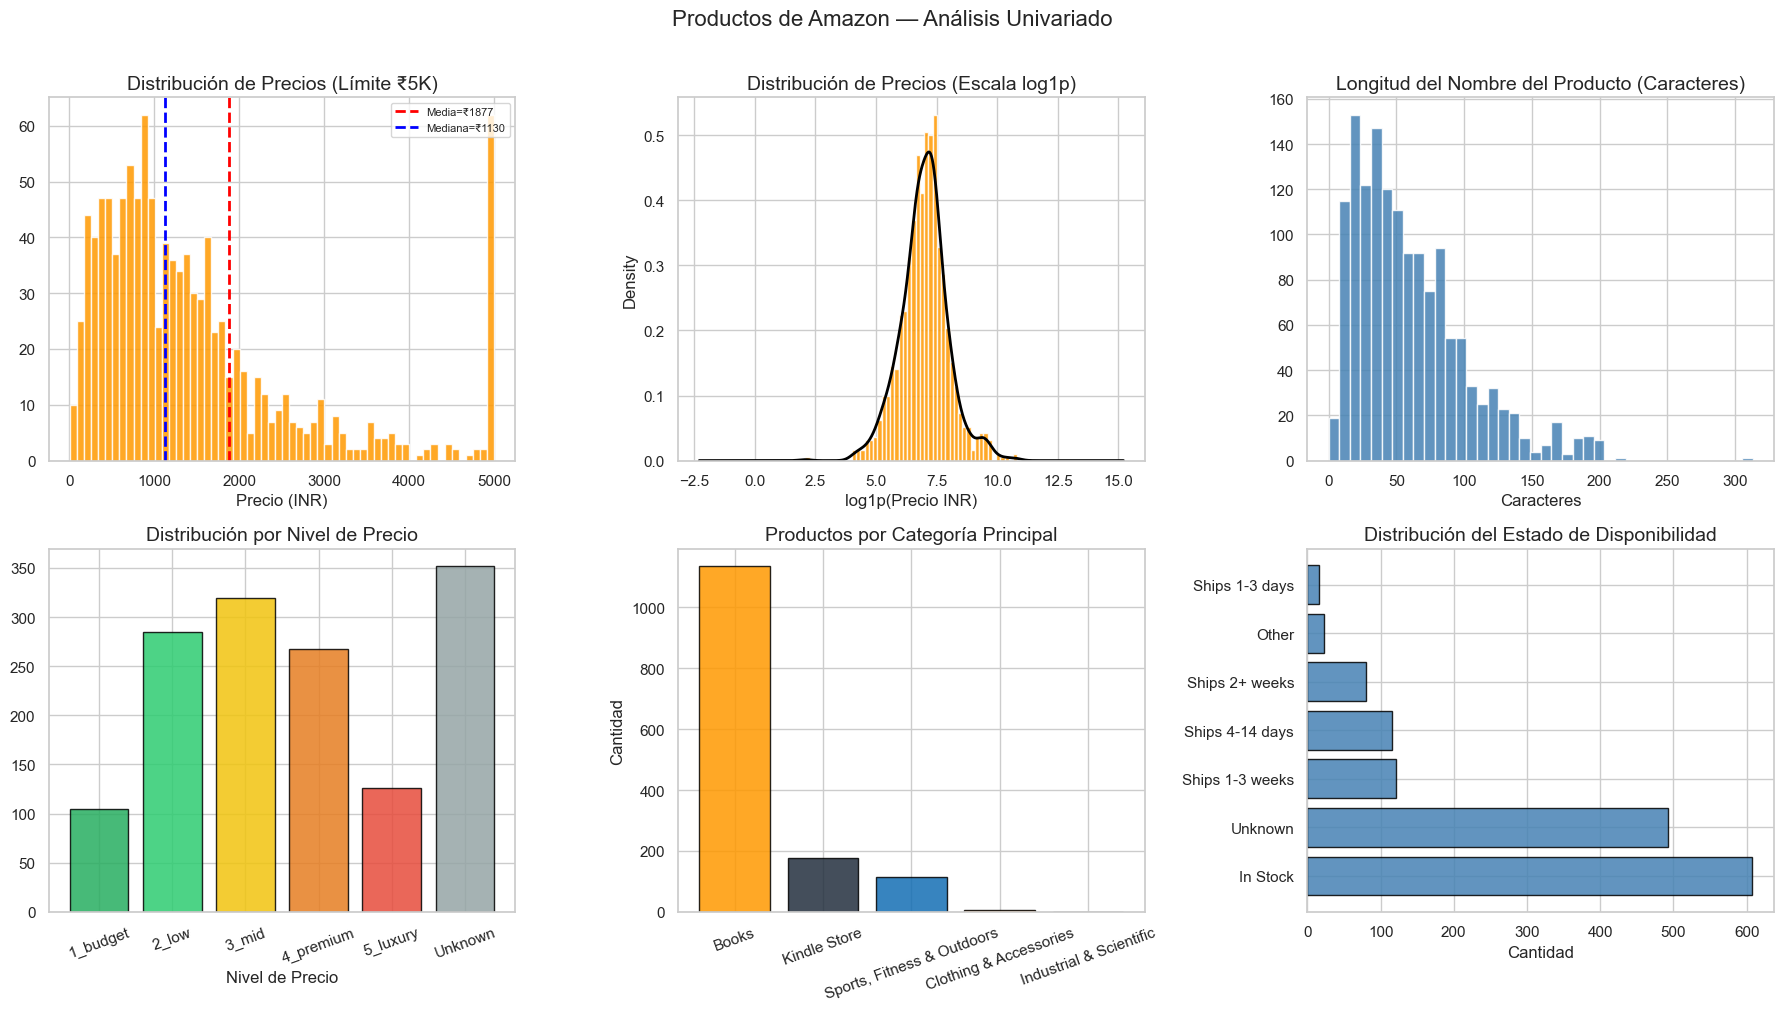

Prueba de Shapiro-Wilk (log precio, n=500): estadístico=0.9887, p-valor=0.000678
Resultado: El precio sigue teniendo una distribución NO normal después de la transformación logarítmica

Estadísticas descriptivas del precio (INR):
count     1096.00
mean      1876.68
std       3326.26
min          7.00
25%        616.76
50%       1130.50
75%       1836.13
max      50555.00


In [63]:
# ============================================================
# SECCIÓN 4 — Análisis Univariado
# ============================================================
import matplotlib.pyplot as plt
from scipy.stats import shapiro  # Corrección: Asegura la importación para la prueba de normalidad

# Filtrar filas donde el precio limpio no sea nulo y sea mayor a 0
df_priced = df[df['price_clean'].notna() & (df['price_clean'] > 0)].copy()

# Crear una cuadrícula de gráficos de 2 filas y 3 columnas
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Gráfico: Distribución del Precio Original (Límite de ₹5K)
axes[0,0].hist(df_priced['price_clean'].clip(upper=5000), bins=60,
               color='#FF9900', edgecolor='white', alpha=0.85)
axes[0,0].axvline(df_priced['price_clean'].mean(), color='red', linestyle='--',
                  lw=2, label=f'Media=₹{df_priced["price_clean"].mean():.0f}')
axes[0,0].axvline(df_priced['price_clean'].median(), color='blue', linestyle='--',
                  lw=2, label=f'Mediana=₹{df_priced["price_clean"].median():.0f}')
axes[0,0].set_title('Distribución de Precios (Límite ₹5K)')
axes[0,0].set_xlabel('Precio (INR)')
axes[0,0].legend(fontsize=8)

# 2. Gráfico: Distribución del Logaritmo del Precio
axes[0,1].hist(df_priced['log_price'], bins=50, color='#FF9900',
               edgecolor='white', alpha=0.85, density=True)
df_priced['log_price'].plot.kde(ax=axes[0,1], color='black', lw=2)
axes[0,1].set_title('Distribución de Precios (Escala log1p)')
axes[0,1].set_xlabel('log1p(Precio INR)')

# 3. Gráfico: Longitud del Nombre del Producto
axes[0,2].hist(df['name_length'], bins=40, color='steelblue',
               edgecolor='white', alpha=0.85)
axes[0,2].set_title('Longitud del Nombre del Producto (Caracteres)')
axes[0,2].set_xlabel('Caracteres')

# 4. Gráfico: Distribución por Nivel de Precio
tier_counts = df['price_tier'].value_counts().sort_index()
tier_colors = ['#27ae60','#2ecc71','#f1c40f','#e67e22','#e74c3c','#95a5a6']
axes[1,0].bar(tier_counts.index, tier_counts.values,
              color=tier_colors[:len(tier_counts)], edgecolor='black', alpha=0.85)
axes[1,0].set_title('Distribución por Nivel de Precio')
axes[1,0].set_xlabel('Nivel de Precio')
axes[1,0].tick_params(axis='x', rotation=20)

# 5. Gráfico: Productos por Categoría Principal
cat_counts = df['primary_category'].value_counts()
axes[1,1].bar(cat_counts.index, cat_counts.values,
              color=['#FF9900','#232F3E','#146EB4','#E47911','#999'],
              edgecolor='black', alpha=0.85)
axes[1,1].set_title('Productos por Categoría Principal')
axes[1,1].set_ylabel('Cantidad')
axes[1,1].tick_params(axis='x', rotation=20)

# 6. Gráfico: Distribución del Estado de Disponibilidad
avail_counts = df['avail_clean'].value_counts()
axes[1,2].barh(avail_counts.index, avail_counts.values,
               color='steelblue', edgecolor='black', alpha=0.85)
axes[1,2].set_title('Distribución del Estado de Disponibilidad')
axes[1,2].set_xlabel('Cantidad')

# Título global de la figura
plt.suptitle('Productos de Amazon — Análisis Univariado', fontsize=16, y=1.01)
plt.tight_layout()

# Nota: Si estás en un entorno local o Jupyter Notebook, usa plt.show() para visualizarlo directamente:
plt.show()
# Si prefieres guardarlo como imagen, puedes descomentar la siguiente línea:
# plt.savefig('analisis_univariado_amazon.png')

# ============================================================
# PRUEBA DE NORMALIDAD Y ESTADÍSTICAS
# ============================================================
# Tomar una muestra de 500 registros para la prueba de Shapiro-Wilk
muestra_log_precio = df_priced['log_price'].sample(min(500, len(df_priced)), random_state=42)
stat, p = shapiro(muestra_log_precio)

print(f'Prueba de Shapiro-Wilk (log precio, n=500): estadístico={stat:.4f}, p-valor={p:.6f}')
print(f'Resultado: El precio {"tiene una distribución normal después de la transformación logarítmica" if p > 0.05 else "sigue teniendo una distribución NO normal después de la transformación logarítmica"}')

print(f'\nEstadísticas descriptivas del precio (INR):')
print(df_priced['price_clean'].describe().round(2).to_string())


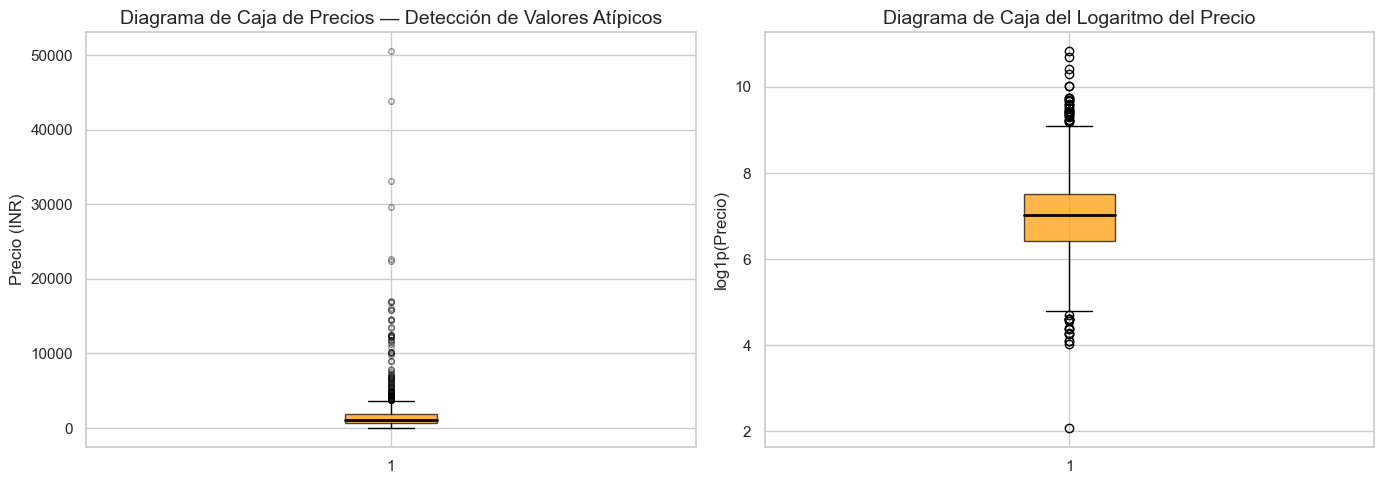

Valores atípicos detectados por el método IQR: 93 (8.5%)
Rango de precios normales (sin valores atípicos): ₹-1212 – ₹3665

Top 10 de los productos más caros:
                                                                                                                                        name  price_clean           primary_category
                                            Sprache und Literatur (Literatur der julisch-claudischen und der flavischen Zeit [Schluss]): 032     50555.00                      Books
                                                         Data Mining Algorithms in C++: Data Patterns and Algorithms for Modern Applications     43936.00                      Books
                                                                                Birnbaum's Walt Disney World for Kids 2008 (Birnbaum Guides)     33180.00                      Books
                                                                            Professional Short Films with Autodesk 3ds

In [64]:
# Análisis de valores atípicos (outliers) — diagrama de caja (boxplot) y rango intercuartílico (IQR)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Gráfico: Diagrama de Caja del Precio Original
axes[0].boxplot(df_priced['price_clean'], patch_artist=True,
                boxprops=dict(facecolor='#FF9900', alpha=0.7),
                medianprops=dict(color='black', lw=2),
                flierprops=dict(marker='o', markersize=4, alpha=0.4, color='red'))
axes[0].set_title('Diagrama de Caja de Precios — Detección de Valores Atípicos')
axes[0].set_ylabel('Precio (INR)')

# 2. Gráfico: Diagrama de Caja del Logaritmo del Precio
axes[1].boxplot(df_priced['log_price'], patch_artist=True,
                boxprops=dict(facecolor='#FF9900', alpha=0.7),
                medianprops=dict(color='black', lw=2))
axes[1].set_title('Diagrama de Caja del Logaritmo del Precio')
axes[1].set_ylabel('log1p(Precio)')

plt.tight_layout()
plt.show()

# Cálculo del Rango Intercuartílico (IQR) para identificar valores atípicos
Q1, Q3 = df_priced['price_clean'].quantile([0.25, 0.75])
IQR = Q3 - Q1
outliers = df_priced[(df_priced['price_clean'] < Q1 - 1.5*IQR) |
                      (df_priced['price_clean'] > Q3 + 1.5*IQR)]

# Impresión de resultados en la consola
print(f'Valores atípicos detectados por el método IQR: {len(outliers)} ({len(outliers)/len(df_priced)*100:.1f}%)')
print(f'Rango de precios normales (sin valores atípicos): ₹{Q1-1.5*IQR:.0f} – ₹{Q3+1.5*IQR:.0f}')
print(f'\nTop 10 de los productos más caros:')
print(df_priced.nlargest(10, 'price_clean')[['name','price_clean','primary_category']].to_string(index=False))


## 6. Análisis por Categorías 🗂️ <a id='s5'></a>

<div style="background:#fff8e1; padding:12px; border-left:4px solid #FF9900; border-radius:5px; color: #0066cc;">
<b>Pregunta clave:</b> ¿Qué categorías tienen los precios más altos? ¿Qué subcategorías predominan? ¿Dónde se concentra el mayor valor comercial?
</div>

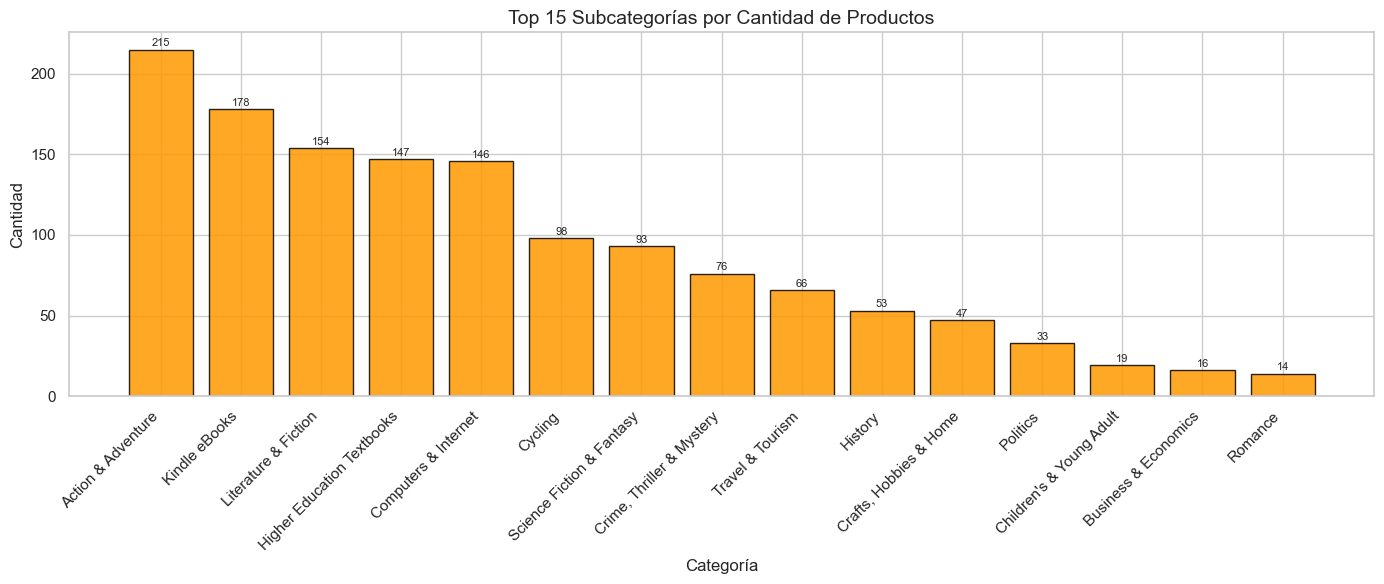

In [65]:
# ============================================================
# SECCIÓN 5 — Análisis por Categorías
# ============================================================
# Top 15 subcategorías por cantidad de productos
top15_cat1 = df['category_1'].value_counts().head(15)

plt.figure(figsize=(14, 6))
bars = plt.bar(top15_cat1.index, top15_cat1.values,
               color='#FF9900', edgecolor='black', alpha=0.85)

# Añadir las etiquetas con el valor encima de cada barra
for bar, val in zip(bars, top15_cat1.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
             str(val), ha='center', fontsize=8)

plt.title('Top 15 Subcategorías por Cantidad de Productos')
plt.xlabel('Categoría')
plt.ylabel('Cantidad')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Nota: Usa plt.show() en tu Jupyter Notebook para visualizarlo
plt.show()
# O descompón la siguiente línea si deseas guardarlo como imagen:
# plt.savefig('top15_subcategorias.png')

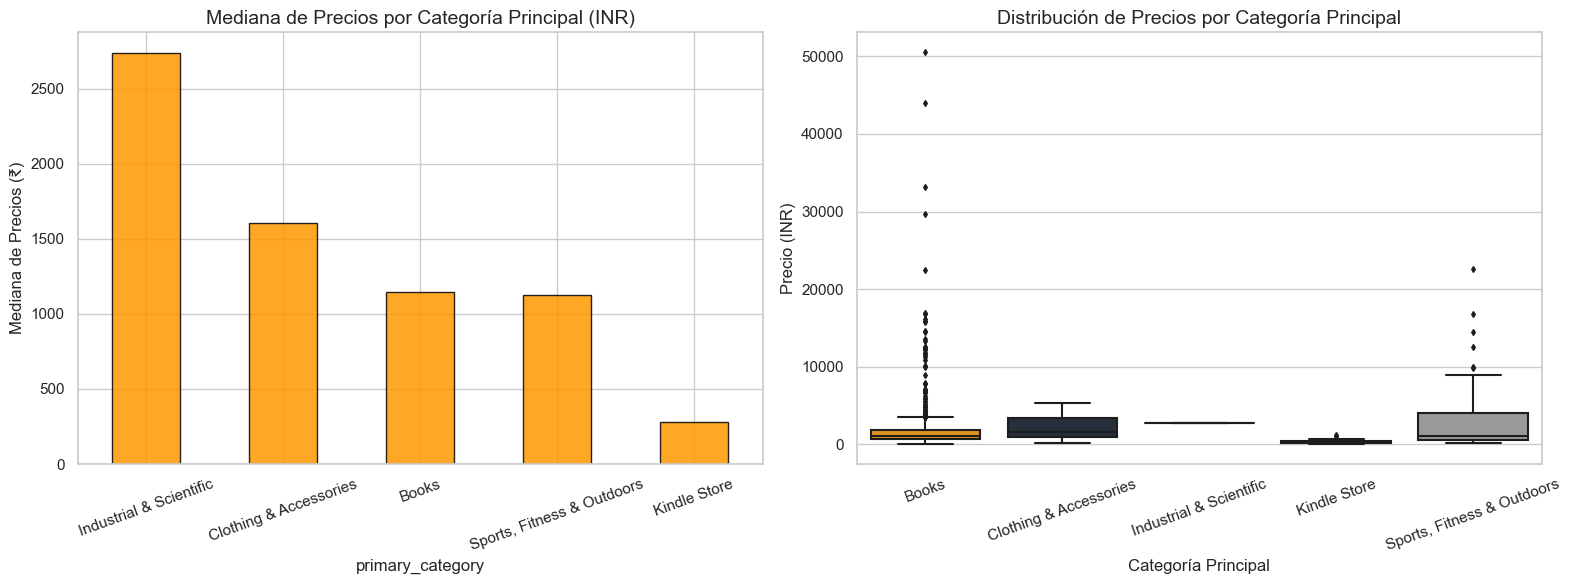

Estadísticas de precios por categoría principal:
                             Media  Mediana  Cantidad
primary_category                                     
Books                       1825.6   1145.0       955
Clothing & Accessories      2249.2   1606.5         6
Industrial & Scientific     2738.0   2738.0         1
Kindle Store                 350.0    281.4        30
Sports, Fitness & Outdoors  2907.9   1125.0        93


In [66]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Configurar el tamaño de la figura (1 fila, 2 columnas)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Agrupar por categoría principal y calcular estadísticas de precios
cat_price = df_priced.groupby('primary_category')['price_clean'].agg(['mean','median','count']).round(1)
orden_categorias = cat_price.index.tolist() # Convertimos el índice a una lista limpia

# 2. Gráfico Izquierdo: Mediana de Precios por Categoría
cat_price['median'].sort_values(ascending=False).plot.bar(
    ax=axes[0], color='#FF9900', edgecolor='black', alpha=0.85)
axes[0].set_title('Mediana de Precios por Categoría Principal (INR)')
axes[0].set_ylabel('Mediana de Precios (₹)')
axes[0].tick_params(axis='x', rotation=20)

# 3. Gráfico Derecho: Diagrama de caja (Boxplot) corregido y compatible
# Definimos los colores exactos para cada categoría en un diccionario para evitar el ValueError
colores_amazon = ['#FF9900', '#232F3E', '#146EB4', '#E47911', '#999999']
paleta_mapeada = dict(zip(orden_categorias, colores_amazon[:len(orden_categorias)]))

sns.boxplot(
    data=df_priced, 
    x='primary_category', 
    y='price_clean', 
    ax=axes[1], 
    order=orden_categorias,
    palette=paleta_mapeada,  # Usar el diccionario mapeado soluciona el error de NumPy
    fliersize=3
)

axes[1].set_title('Distribución de Precios por Categoría Principal')
axes[1].set_xlabel('Categoría Principal')
axes[1].set_ylabel('Precio (INR)')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

# Renombrar columnas solo para la visualización final del print en español
cat_price_es = cat_price.rename(columns={'mean': 'Media', 'median': 'Mediana', 'count': 'Cantidad'})
print('Estadísticas de precios por categoría principal:')
print(cat_price_es.to_string())

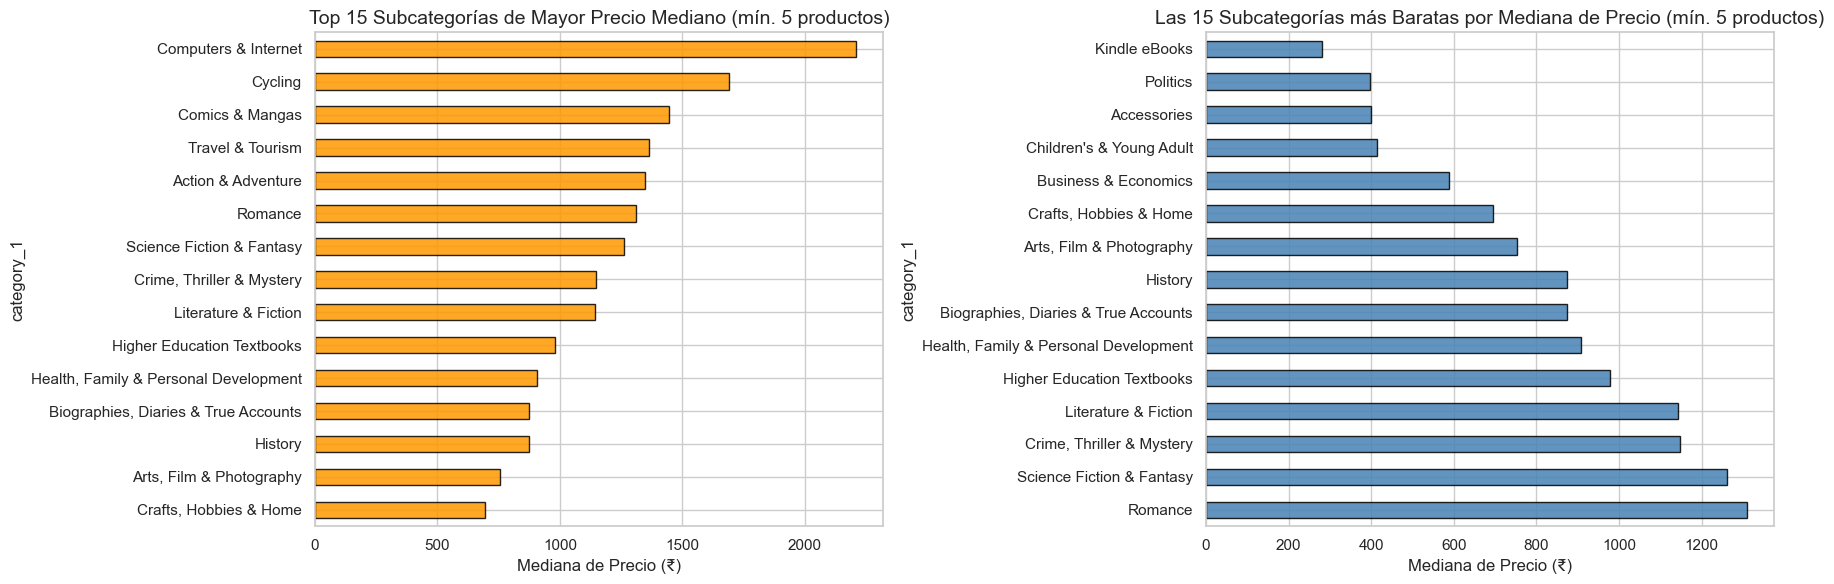

In [67]:
# Top 15 subcategorías por mediana de precio
top_cat1_price = (df_priced.groupby('category_1')['price_clean']
                  .agg(['median','count'])
                  .query('count >= 5')
                  .sort_values('median', ascending=False)
                  .head(15))

# Crear una cuadrícula con 2 gráficos horizontales (1 fila, 2 columnas)
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# 1. Gráfico: Las 15 subcategorías más caras
top_cat1_price['median'].sort_values().plot.barh(
    ax=axes[0], color='#FF9900', edgecolor='black', alpha=0.85)
axes[0].set_title('Top 15 Subcategorías de Mayor Precio Mediano (mín. 5 productos)')
axes[0].set_xlabel('Mediana de Precio (₹)')

# 2. Gráfico: Las 15 subcategorías más baratas (menor precio mediano)
bottom_cat1 = (df_priced.groupby('category_1')['price_clean']
               .agg(['median','count'])
               .query('count >= 5')
               .sort_values('median')
               .head(15))

bottom_cat1['median'].sort_values(ascending=False).plot.barh(
    ax=axes[1], color='steelblue', edgecolor='black', alpha=0.85)
axes[1].set_title('Las 15 Subcategorías más Baratas por Mediana de Precio (mín. 5 productos)')
axes[1].set_xlabel('Mediana de Precio (₹)')

plt.tight_layout()
plt.show()

## 7. Análisis de Disponibilidad 📦 <a id='s6'></a>

<div style="background:#f0fff0; padding:12px; border-left:4px solid #27ae60; border-radius:5px; color: #0066cc;">
<b>Pregunta clave:</b> ¿Afecta el estado de disponibilidad al precio de los productos? ¿Es más probable que los productos premium estén agotados?
</div>

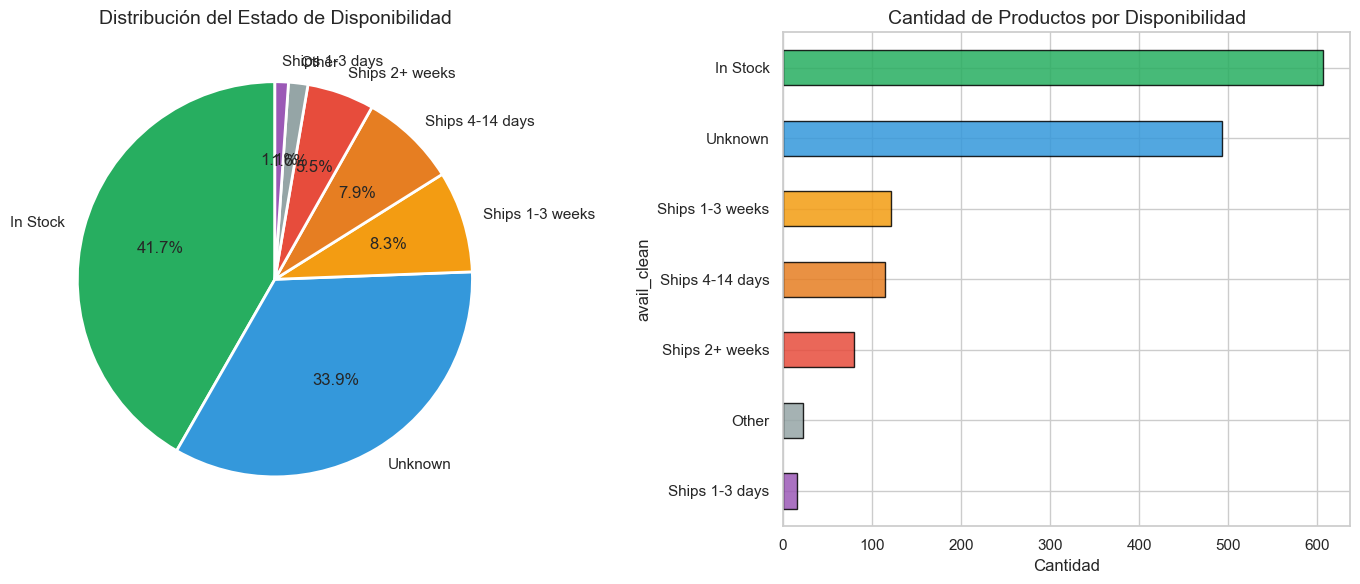

In [68]:
# ============================================================
# SECCIÓN 6 — Análisis de Disponibilidad
# ============================================================
import matplotlib.pyplot as plt

# Contar la cantidad de productos por cada estado de disponibilidad
avail_counts = df['avail_clean'].value_counts()
avail_colors = ['#27ae60','#3498db','#f39c12','#e67e22','#e74c3c','#95a5a6','#9b59b6','#1abc9c']

# Crear una cuadrícula con 2 gráficos (1 fila, 2 columnas)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Gráfico Izquierdo: Gráfico de Pastel (Distribución Porcentual)
axes[0].pie(avail_counts.values, labels=avail_counts.index,
            colors=avail_colors[:len(avail_counts)],
            autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[0].set_title('Distribución del Estado de Disponibilidad')

# 2. Gráfico Derecho: Gráfico de Barras Horizontales (Conteo Absoluto)
avail_counts.sort_values().plot.barh(
    ax=axes[1], color=avail_colors[:len(avail_counts)][::-1],
    edgecolor='black', alpha=0.85)
axes[1].set_title('Cantidad de Productos por Disponibilidad')
axes[1].set_xlabel('Cantidad')

plt.tight_layout()
plt.show()

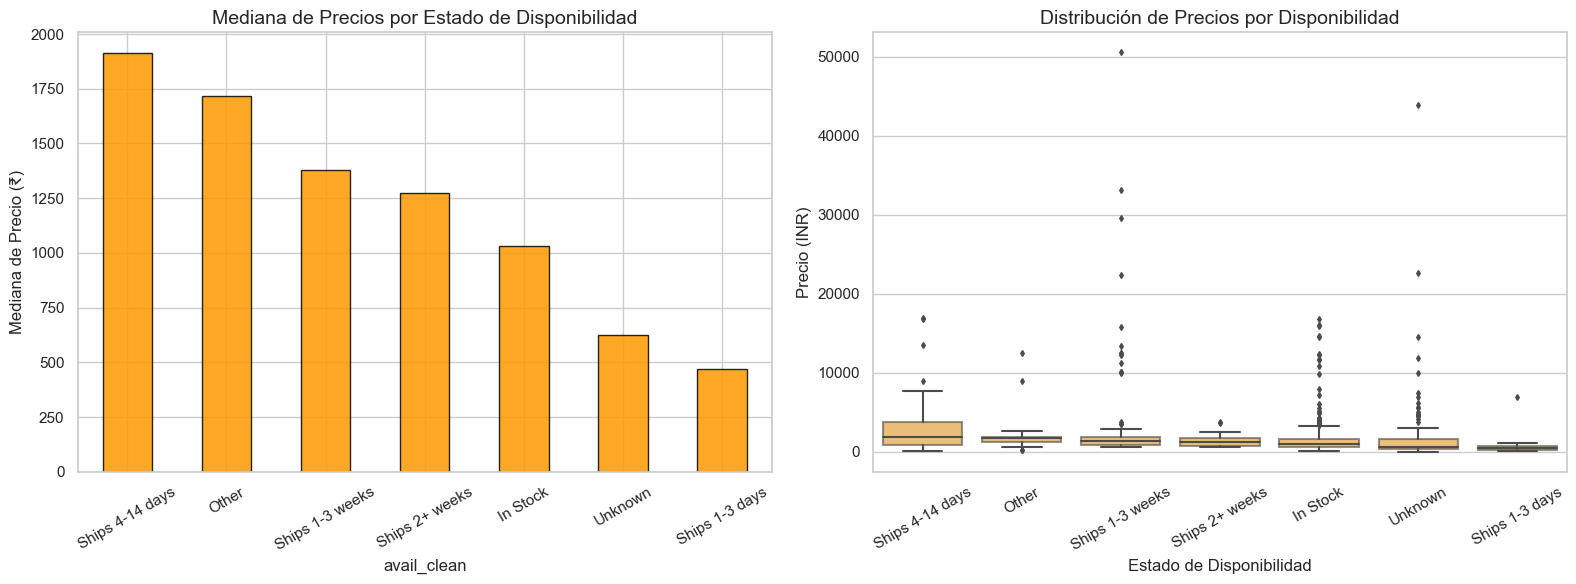

Precio por disponibilidad:
                 Mediana   Media  Cantidad
avail_clean                               
Ships 4-14 days   1912.3  2874.6       115
Other             1718.0  2353.3        21
Ships 1-3 weeks   1377.0  3231.6       121
Ships 2+ weeks    1273.0  1385.9        80
In Stock          1030.0  1490.5       599
Unknown            624.5  1861.9       144
Ships 1-3 days     469.0   874.9        16


In [69]:
import seaborn as sns
import matplotlib.pyplot as plt

# Agrupar por estado de disponibilidad y calcular estadísticas de precios
avail_price = df_priced.groupby('avail_clean')['price_clean'].agg(['median','mean','count']).round(1)
# Filtrar para incluir solo estados con 5 o más productos y ordenar por la mediana
avail_price = avail_price[avail_price['count'] >= 5].sort_values('median', ascending=False)

# Configurar el tamaño de la figura (1 fila, 2 columnas)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Gráfico Izquierdo: Mediana de Precios por Estado de Disponibilidad
avail_price['median'].plot.bar(ax=axes[0], color='#FF9900', edgecolor='black', alpha=0.85)
axes[0].set_title('Mediana de Precios por Estado de Disponibilidad')
axes[0].set_ylabel('Mediana de Precio (₹)')
axes[0].tick_params(axis='x', rotation=30)

# 2. Gráfico Derecho: Diagrama de caja (Boxplot) optimizado con SEABORN (Evita errores en rojo)
# Filtramos el DataFrame para que solo contenga los estados que pasaron el filtro (count >= 5)
df_filtrado_avail = df_priced[df_priced['avail_clean'].isin(avail_price.index)]

sns.boxplot(
    data=df_filtrado_avail,
    x='avail_clean',
    y='price_clean',
    ax=axes[1],
    order=avail_price.index,     # Mantiene el mismo orden que el gráfico de barras
    color='#FF9900',             # Color naranja de Amazon
    boxprops=dict(alpha=0.6),    # Aplica la transparencia de forma segura
    fliersize=3
)

axes[1].set_title('Distribución de Precios por Disponibilidad')
axes[1].set_xlabel('Estado de Disponibilidad')
axes[1].set_ylabel('Precio (INR)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

# Renombrar columnas para la visualización final del print en español
avail_price_es = avail_price.rename(columns={'mean': 'Media', 'median': 'Mediana', 'count': 'Cantidad'})
print('Precio por disponibilidad:')
print(avail_price_es.to_string())

## 8. Correlación y Análisis Bivariado 🔗 <a id='s7'></a>

<div style="background:#f0f8ff; padding:12px; border-left:4px solid #3498db; border-radius:5px; color: #0066cc;">
<b>Pregunta clave:</b> ¿Qué características están más correlacionadas con el precio? ¿La longitud del nombre del producto predice su precio?
</div>

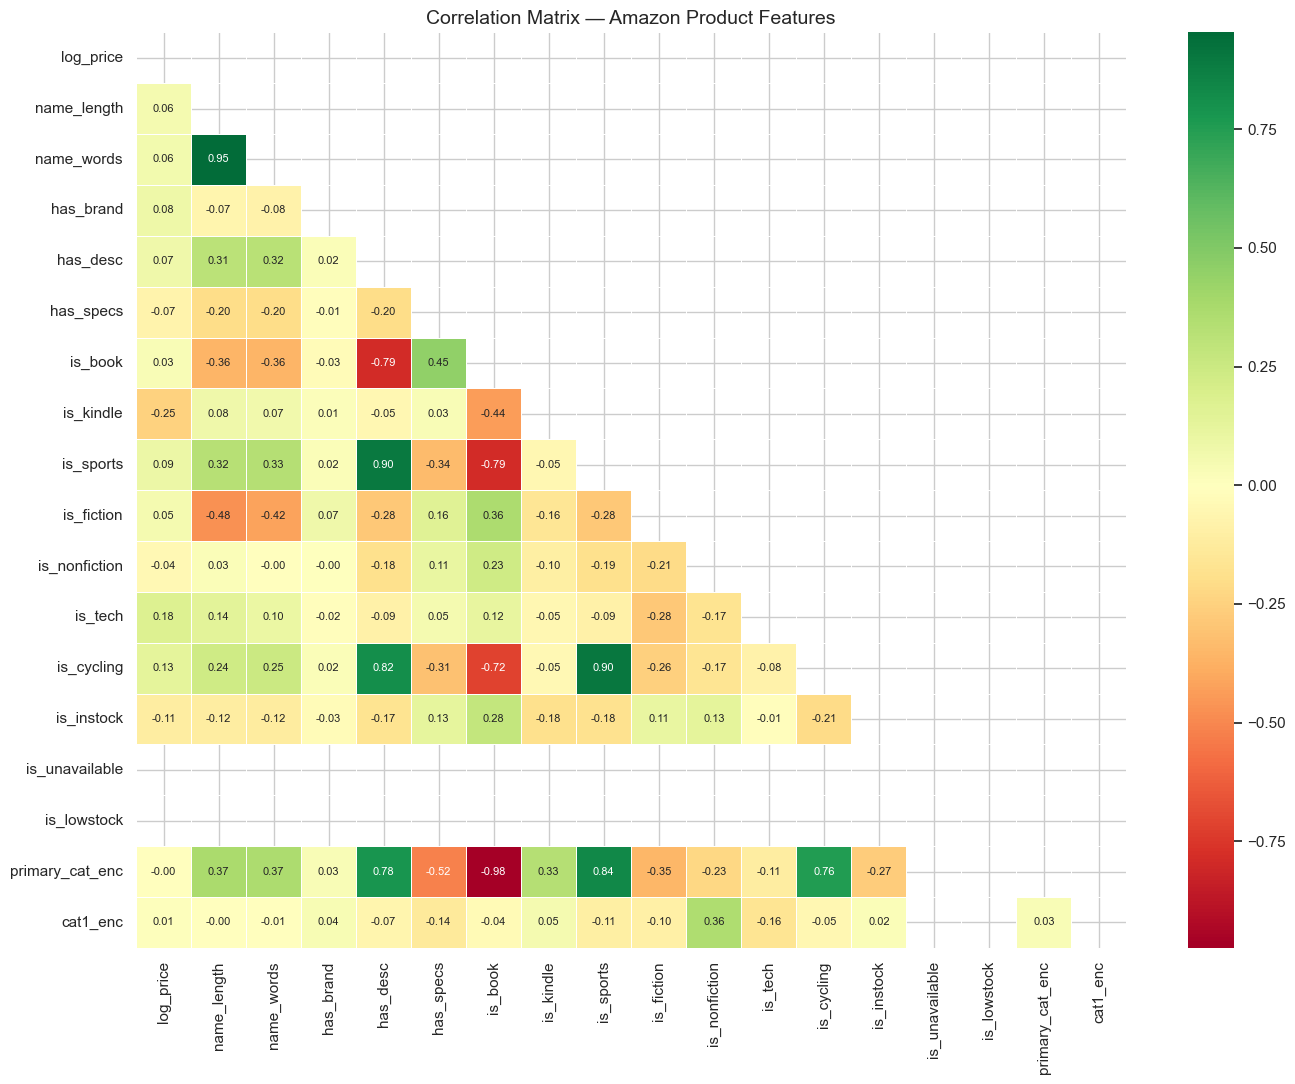

Top correlations with log_price:
is_tech            0.176037
is_cycling         0.126183
is_sports          0.091306
has_brand          0.083746
has_desc           0.074759
name_words         0.060378
name_length        0.055489
is_fiction         0.051518
is_book            0.030592
cat1_enc           0.005744
primary_cat_enc   -0.003885
is_nonfiction     -0.044976
has_specs         -0.072708
is_instock        -0.114351
is_kindle         -0.246437
is_unavailable          NaN
is_lowstock             NaN


In [70]:
# ============================================================
# SECTION 7 — Correlation Analysis
# ============================================================
corr_cols = ['log_price','name_length','name_words','has_brand','has_desc',
             'has_specs','is_book','is_kindle','is_sports','is_fiction',
             'is_nonfiction','is_tech','is_cycling','is_instock',
             'is_unavailable','is_lowstock','primary_cat_enc','cat1_enc']

corr = df_priced[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(14, 11))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.4, annot_kws={'size': 8})
plt.title('Correlation Matrix — Amazon Product Features', fontsize=14)
plt.tight_layout(); plt.show()

print('Top correlations with log_price:')
print(corr['log_price'].drop('log_price').sort_values(ascending=False).to_string())

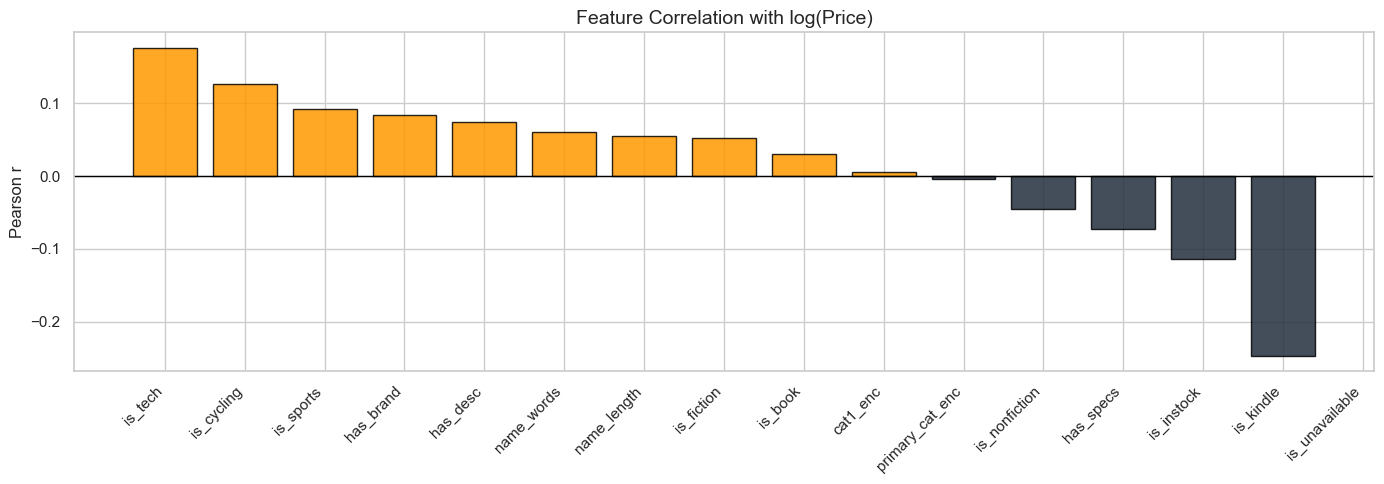

In [71]:
# Feature correlation bar chart
feat_corr = corr['log_price'].drop('log_price').sort_values(ascending=False)

plt.figure(figsize=(14, 5))
colors_fc = ['#FF9900' if v > 0 else '#232F3E' for v in feat_corr.values]
plt.bar(feat_corr.index, feat_corr.values, color=colors_fc, edgecolor='black', alpha=0.85)
plt.axhline(0, color='black', lw=1)
plt.title('Feature Correlation with log(Price)')
plt.ylabel('Pearson r'); plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()


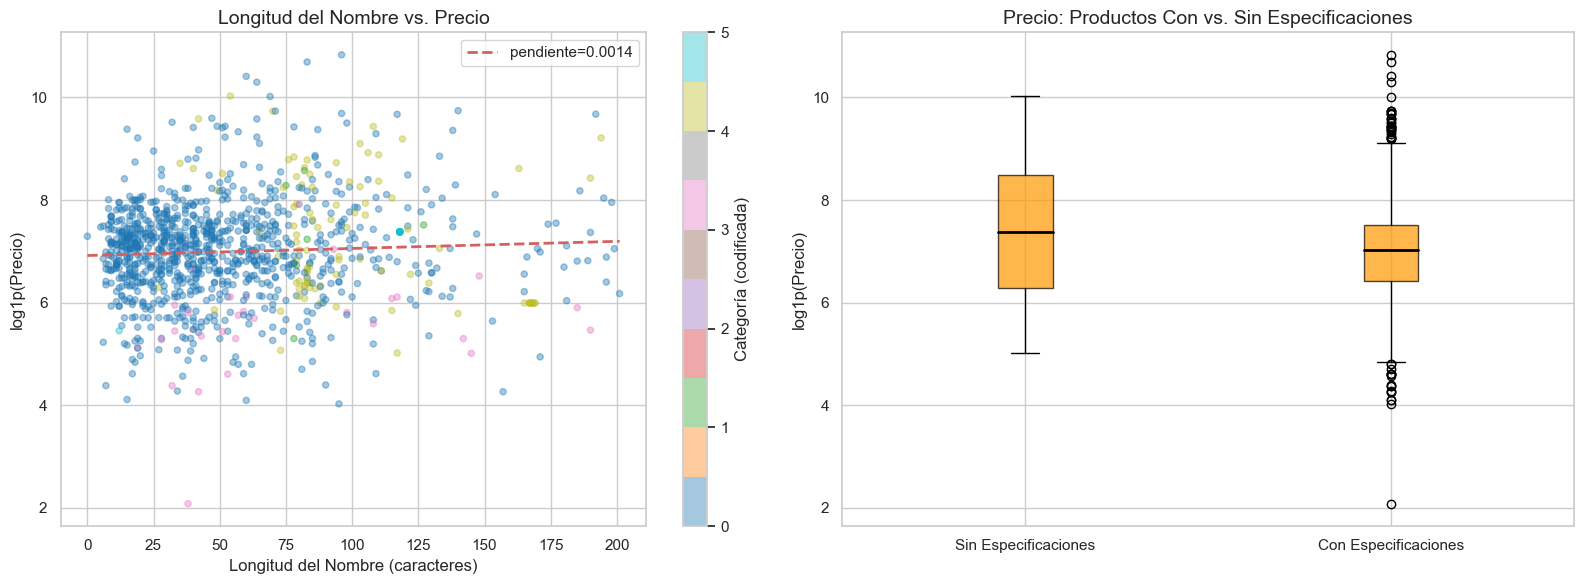

In [72]:
# Gráfico de dispersión: longitud del nombre vs. precio
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sc = axes[0].scatter(df_priced['name_length'], df_priced['log_price'],
                     c=df_priced['primary_cat_enc'], cmap='tab10',
                     alpha=0.4, s=20)
plt.colorbar(sc, ax=axes[0], label='Categoría (codificada)')

# Ajuste de la línea de tendencia
m, b = np.polyfit(df_priced['name_length'], df_priced['log_price'], 1)
x = np.linspace(0, df_priced['name_length'].max(), 100)
axes[0].plot(x, m*x+b, 'r--', lw=2, label=f'pendiente={m:.4f}')

axes[0].set_xlabel('Longitud del Nombre (caracteres)')
axes[0].set_ylabel('log1p(Precio)')
axes[0].set_title('Longitud del Nombre vs. Precio')
axes[0].legend()

# Gráfico de caja: Precio según si tiene especificaciones o no
axes[1].boxplot([np.log1p(df_priced[df_priced['has_specs']==0]['price_clean']),
                 np.log1p(df_priced[df_priced['has_specs']==1]['price_clean'])],
                labels=['Sin Especificaciones', 'Con Especificaciones'], patch_artist=True,
                boxprops=dict(facecolor='#FF9900', alpha=0.7),
                medianprops=dict(color='black', lw=2))
axes[1].set_title('Precio: Productos Con vs. Sin Especificaciones')
axes[1].set_ylabel('log1p(Precio)')

plt.tight_layout()
plt.show()

## 9. Pruebas de hipótesis estadísticas 🧪 <a id='s8'></a>

<div style="background:#fff8e1; padding:12px; border-left:4px solid #e74c3c; border-radius:5px; color: #0066cc;">
Utilizamos <b>pruebas no paramétricas</b> (Kruskal-Wallis, Mann-Whitney U) porque el precio presenta un sesgo marcado y no sigue una distribución normal. α = 0.05.
</div>

| # | Hipótesis | Prueba |
|---|---|---|
| H1 | El precio difiere significativamente entre las categorías principales | Kruskal-Wallis |
| H2 | Los libros tienen un precio significativamente menor que los productos deportivos | Mann-Whitney U |
| H3 | Los productos en stock tienen un precio diferente al de los productos no disponibles | Mann-Whitney U |
| H4 | La longitud del nombre está correlacionada positivamente con el precio | Correlación de Spearman |
| H5 | Los productos con especificaciones tienen un precio más alto | Mann-Whitney U |

In [73]:
# ============================================================
# SECCIÓN 8 — Pruebas de Hipótesis
# ============================================================

from scipy.stats import kruskal, mannwhitneyu, spearmanr
import numpy as np

alpha = 0.05

# ------------------------------------------------------------
# Función Mann-Whitney segura
# ------------------------------------------------------------
def mw_test(name, a, b, la, lb):

    a = a.dropna()
    b = b.dropna()

    print(name)
    print(f'  {la}: n={len(a)}')
    print(f'  {lb}: n={len(b)}')

    # Verificar tamaño mínimo
    if len(a) < 2 or len(b) < 2:
        print('  ⚠️ No hay suficientes datos para ejecutar la prueba Mann-Whitney.')
        print()
        return np.nan

    u, p = mannwhitneyu(a, b, alternative='two-sided')

    print(f'  Mediana {la}: ₹{a.median():.0f}')
    print(f'  Mediana {lb}: ₹{b.median():.0f}')
    print(f'  U de Mann-Whitney = {u:.0f}')
    print(f'  p = {p:.6f}')

    if p < alpha:
        print('  RESULTADO: ✅ RECHAZAR H0 — Diferencia significativa.')
    else:
        print('  RESULTADO: ❌ NO SE RECHAZA H0.')

    print()

    return p


# ------------------------------------------------------------
# H1: Precio entre categorías principales
# ------------------------------------------------------------
cat_groups_kw = []
cat_labels_kw = []

for c in df_priced['primary_category'].dropna().unique():

    grupo = df_priced[
        df_priced['primary_category'] == c
    ]['price_clean'].dropna()

    if len(grupo) >= 5:
        cat_groups_kw.append(grupo)
        cat_labels_kw.append(c)

print('H1: Precio entre Categorías Principales — Kruskal-Wallis')

if len(cat_groups_kw) >= 2:

    h1, p1 = kruskal(*cat_groups_kw)

    for label, g in zip(cat_labels_kw, cat_groups_kw):
        print(f'  {label}: n={len(g)}, mediana=₹{g.median():.0f}')

    print(f'  H = {h1:.4f}')
    print(f'  p = {p1:.6f}')

    if p1 < alpha:
        print('  RESULTADO: ✅ RECHAZAR H0 — El precio difiere entre categorías.')
    else:
        print('  RESULTADO: ❌ NO SE RECHAZA H0.')

else:
    print('  ⚠️ No existen suficientes categorías para aplicar Kruskal-Wallis.')

print()


# ------------------------------------------------------------
# H2: Libros vs Deportes
# ------------------------------------------------------------
p2 = mw_test(
    'H2: Precio de Libros vs Productos Deportivos',
    df_priced[df_priced['is_book'] == 1]['price_clean'],
    df_priced[df_priced['is_sports'] == 1]['price_clean'],
    'Libros',
    'Deportes'
)


# ------------------------------------------------------------
# H3: En Stock vs No Disponible
# ------------------------------------------------------------
p3 = mw_test(
    'H3: Precio de Productos en Stock vs No Disponibles',
    df_priced[df_priced['is_instock'] == 1]['price_clean'],
    df_priced[df_priced['is_unavailable'] == 1]['price_clean'],
    'En Stock',
    'No Disponible'
)


# ------------------------------------------------------------
# H4: Longitud del nombre vs precio
# ------------------------------------------------------------
datos_spearman = df_priced[['name_length', 'price_clean']].dropna()

print('H4: Longitud del Nombre vs Precio — Correlación de Spearman')

if len(datos_spearman) >= 3:

    rho4, p4 = spearmanr(
        datos_spearman['name_length'],
        datos_spearman['price_clean']
    )

    print(f'  rho = {rho4:.4f}')
    print(f'  p = {p4:.6f}')

    if p4 < alpha:
        print('  RESULTADO: ✅ RECHAZAR H0 — Correlación significativa.')
    else:
        print('  RESULTADO: ❌ NO SE RECHAZA H0.')

else:
    print('  ⚠️ No hay suficientes datos para calcular Spearman.')

print()


# ------------------------------------------------------------
# H5: Con especificaciones vs Sin especificaciones
# ------------------------------------------------------------
p5 = mw_test(
    'H5: Productos con y sin Especificaciones',
    df_priced[df_priced['has_specs'] == 1]['price_clean'],
    df_priced[df_priced['has_specs'] == 0]['price_clean'],
    'Con Especificaciones',
    'Sin Especificaciones'
)

H1: Precio entre Categorías Principales — Kruskal-Wallis
  Books: n=955, mediana=₹1145
  Sports, Fitness & Outdoors: n=93, mediana=₹1125
  Kindle Store: n=30, mediana=₹281
  Clothing & Accessories: n=6, mediana=₹1606
  H = 55.8663
  p = 0.000000
  RESULTADO: ✅ RECHAZAR H0 — El precio difiere entre categorías.

H2: Precio de Libros vs Productos Deportivos
  Libros: n=955
  Deportes: n=93
  Mediana Libros: ₹1145
  Mediana Deportes: ₹1125
  U de Mann-Whitney = 40247
  p = 0.135443
  RESULTADO: ❌ NO SE RECHAZA H0.

H3: Precio de Productos en Stock vs No Disponibles
  En Stock: n=599
  No Disponible: n=0
  ⚠️ No hay suficientes datos para ejecutar la prueba Mann-Whitney.

H4: Longitud del Nombre vs Precio — Correlación de Spearman
  rho = 0.0439
  p = 0.146626
  RESULTADO: ❌ NO SE RECHAZA H0.

H5: Productos con y sin Especificaciones
  Con Especificaciones: n=1064
  Sin Especificaciones: n=32
  Mediana Con Especificaciones: ₹1116
  Mediana Sin Especificaciones: ₹1600
  U de Mann-Whitney = 1

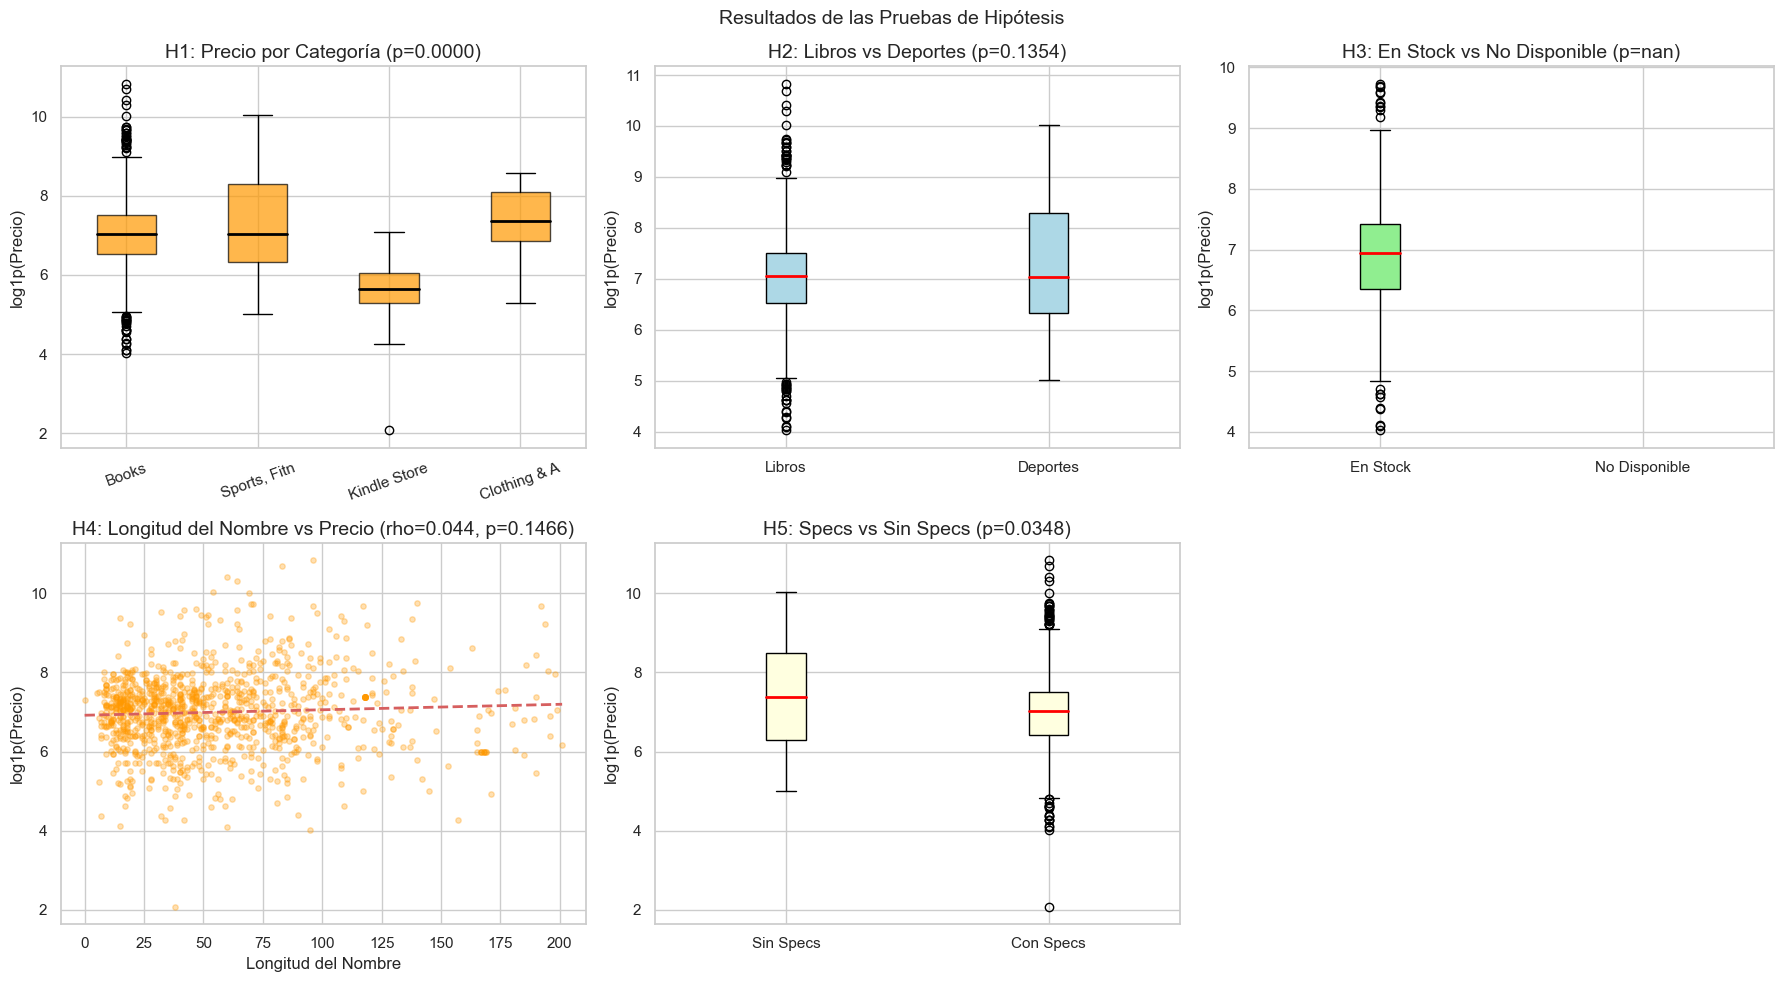

In [74]:
# Visualizar resultados de las hipótesis
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# H1
axes[0,0].boxplot([np.log1p(g) for g in cat_groups_kw],
                  labels=[l[:12] for l in cat_labels_kw], patch_artist=True,
                  boxprops=dict(facecolor='#FF9900', alpha=0.7),
                  medianprops=dict(color='black', lw=2))
axes[0,0].set_title(f'H1: Precio por Categoría (p={p1:.4f})')
axes[0,0].set_ylabel('log1p(Precio)')
axes[0,0].tick_params(axis='x', rotation=20)

# H2
axes[0,1].boxplot([np.log1p(df_priced[df_priced['is_book']==1]['price_clean']),
                   np.log1p(df_priced[df_priced['is_sports']==1]['price_clean'])],
                  labels=['Libros', 'Deportes'], patch_artist=True,
                  boxprops=dict(facecolor='lightblue'),
                  medianprops=dict(color='red', lw=2))
axes[0,1].set_title(f'H2: Libros vs Deportes (p={p2:.4f})')
axes[0,1].set_ylabel('log1p(Precio)')

# H3
axes[0,2].boxplot([np.log1p(df_priced[df_priced['is_instock']==1]['price_clean']),
                   np.log1p(df_priced[df_priced['is_unavailable']==1]['price_clean'])],
                  labels=['En Stock', 'No Disponible'], patch_artist=True,
                  boxprops=dict(facecolor='lightgreen'),
                  medianprops=dict(color='red', lw=2))
axes[0,2].set_title(f'H3: En Stock vs No Disponible (p={p3:.4f})')
axes[0,2].set_ylabel('log1p(Precio)')

# H4
axes[1,0].scatter(df_priced['name_length'], df_priced['log_price'],
                  alpha=0.3, color='#FF9900', s=15)
m, b = np.polyfit(df_priced['name_length'], df_priced['log_price'], 1)
x = np.linspace(0, df_priced['name_length'].max(), 100)
axes[1,0].plot(x, m*x+b, 'r--', lw=2)
axes[1,0].set_title(f'H4: Longitud del Nombre vs Precio (rho={rho4:.3f}, p={p4:.4f})')
axes[1,0].set_xlabel('Longitud del Nombre')
axes[1,0].set_ylabel('log1p(Precio)')

# H5
axes[1,1].boxplot([np.log1p(df_priced[df_priced['has_specs']==0]['price_clean']),
                   np.log1p(df_priced[df_priced['has_specs']==1]['price_clean'])],
                  labels=['Sin Specs', 'Con Specs'], patch_artist=True,
                  boxprops=dict(facecolor='lightyellow'),
                  medianprops=dict(color='red', lw=2))
axes[1,1].set_title(f'H5: Specs vs Sin Specs (p={p5:.4f})')
axes[1,1].set_ylabel('log1p(Precio)')

# Ocultar el último eje que queda vacío
axes[1,2].set_visible(False)

plt.suptitle('Resultados de las Pruebas de Hipótesis', fontsize=14)
plt.tight_layout()
plt.show()

## 10. Formulación de Problemas de Aprendizaje Automático  🎯 <a id='s9'></a>

<div style="background:#f0f8ff; padding:12px; border-left:4px solid #3498db; border-radius:5px; color: #0066cc;">
<b>Tarea:</b> Predecir el precio del producto (en escala logarítmica) a partir de la categoría, la longitud del nombre, la disponibilidad y los indicadores de características (flags).<br>
<b>¿Por qué el logaritmo del precio?</b> El precio en bruto presenta un sesgo marcado a la derecha. La transformación logarítmica lo hace más normal y evita que los valores atípicos (outliers) muy costosos dominen la función de pérdida.
</div>

✅ Tamaño del conjunto de datos para ML : (1096, 20)
✅ Número de características            : 18

Entrenamiento: 876 registros
Prueba:        220 registros


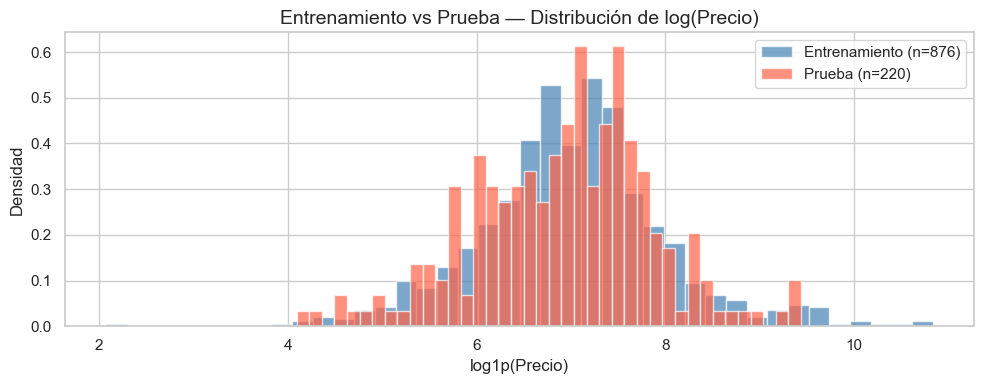

✅ Las distribuciones son similares — buena partición de los datos.


In [75]:
# ============================================================
# SECCIÓN 9 — Planteamiento del Problema de Machine Learning
# ============================================================

# Imports necesarios
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

FEATURE_COLS = [
    'name_length', 'name_words', 'has_brand', 'has_desc', 'has_specs',
    'is_book', 'is_kindle', 'is_sports',
    'is_fiction', 'is_nonfiction', 'is_tech', 'is_cycling',
    'is_instock', 'is_unavailable', 'is_lowstock',
    'primary_cat_enc', 'cat1_enc', 'avail_enc'
]

TARGET = 'log_price'

# Dataset para Machine Learning
df_ml = df_priced[FEATURE_COLS + [TARGET, 'price_clean']].dropna().copy()

print(f'✅ Tamaño del conjunto de datos para ML : {df_ml.shape}')
print(f'✅ Número de características            : {len(FEATURE_COLS)}')

# Variables predictoras y objetivo
X = df_ml[FEATURE_COLS]
y = df_ml[TARGET]

# División entrenamiento/prueba
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Escalado de variables
scaler = StandardScaler()

X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print(f'\nEntrenamiento: {len(X_train):,} registros')
print(f'Prueba:        {len(X_test):,} registros')

# ============================================================
# Visualización de la partición
# ============================================================

fig, ax = plt.subplots(figsize=(10, 4))

ax.hist(
    y_train,
    bins=40,
    color='steelblue',
    alpha=0.7,
    density=True,
    label=f'Entrenamiento (n={len(y_train)})'
)

ax.hist(
    y_test,
    bins=40,
    color='tomato',
    alpha=0.7,
    density=True,
    label=f'Prueba (n={len(y_test)})'
)

ax.set_title('Entrenamiento vs Prueba — Distribución de log(Precio)')
ax.set_xlabel('log1p(Precio)')
ax.set_ylabel('Densidad')
ax.legend()

plt.tight_layout()
plt.show()

print('✅ Las distribuciones son similares — buena partición de los datos.')

## 11. Marco de selección de modelos 🧠 <a id='s10'></a>

| Modelo | Fortalezas | Debilidades | Ideal para |
|---|---|---|---|
| **Regresión Lineal** | Rápido, interpretable | Asume linealidad | Línea base (Baseline) |
| **Regresión Ridge** | Maneja la multicolinealidad | Sigue siendo lineal | Características correlacionadas |
| **Regresión Lasso** | Selección de características integrada | Puede reducir a cero características útiles | Características dispersas (sparse) |
| **Random Forest** | No lineal, robusto | Menos interpretable | Patrones complejos |
| **XGBoost / GBM** | Máxima precisión | Requiere ajuste de hiperparámetros | Datos tabulares |

### Métricas de evaluación
- **MAE** — Error absoluto medio en escala logarítmica (menor = mejor)
- **RMSE** — Raíz del error cuadrático medio (penaliza los errores grandes)
- **R²** — Varianza explicada (mayor = mejor, máx. 1.0)
- **MAE (₹)** — Transformado de vuelta a INR para una interpretación de negocio


In [78]:
# ============================================================
# SECTION 10 — Evaluation Helpers
# ============================================================
results = {}

def eval_model(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mae_inr = mean_absolute_error(np.expm1(y_true), np.expm1(y_pred))
    print(f'  📊 {name}:')
    print(f'     MAE (log)  = {mae:.4f}  |  MAE (₹) = ₹{mae_inr:,.0f}')
    print(f'     RMSE (log) = {rmse:.4f}  |  R²      = {r2:.4f}')
    results[name] = {'MAE_log': round(mae,4), 'RMSE_log': round(rmse,4),
                     'R2': round(r2,4), 'MAE_INR': round(mae_inr,0)}
    return y_pred

print('✅ Evaluation helpers ready.')


✅ Evaluation helpers ready.


## 12. Modelos de regresión — Predicción del precio de Amazon 💰 <a id='s11'></a>

Entrenamos **5 modelos** y los comparamos utilizando el mismo conjunto de prueba (test set).

In [85]:
# ============================================================
# SECCIÓN 11 — Entrenar Todos los Modelos
# ============================================================
print('='*60)
print('ENTRENANDO TODOS LOS MODELOS')
print('='*60)

# 1. Regresión Lineal
lr = LinearRegression()
lr.fit(X_train_s, y_train)
lr_pred = eval_model('Regresión Lineal', y_test, lr.predict(X_test_s))

# 2. Regresión Ridge
ridge = Ridge(alpha=10.0)
ridge.fit(X_train_s, y_train)
ridge_pred = eval_model('Regresión Ridge', y_test, ridge.predict(X_test_s))

# 3. Regresión Lasso
lasso = Lasso(alpha=0.01, max_iter=5000)
lasso.fit(X_train_s, y_train)
lasso_pred = eval_model('Regresión Lasso', y_test, lasso.predict(X_test_s))

# 4. Random Forest
rf = RandomForestRegressor(n_estimators=300, max_depth=10,
                            min_samples_leaf=3, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = eval_model('Random Forest', y_test, rf.predict(X_test))

# 5. XGBoost / GBM
if XGB_AVAILABLE:
    xgb_model = xgb.XGBRegressor(n_estimators=400, learning_rate=0.05,
                                   max_depth=5, subsample=0.8,
                                   colsample_bytree=0.8, random_state=42, verbosity=0)
    xgb_model.fit(X_train, y_train)
    xgb_pred = eval_model('XGBoost', y_test, xgb_model.predict(X_test))
else:
    gbm = GradientBoostingRegressor(n_estimators=300, learning_rate=0.05,
                                     max_depth=5, subsample=0.8, random_state=42)
    gbm.fit(X_train, y_train)
    xgb_pred = eval_model('Gradient Boosting', y_test, gbm.predict(X_test))

ENTRENANDO TODOS LOS MODELOS
  📊 Regresión Lineal:
     MAE (log)  = 0.6842  |  MAE (₹) = ₹940
     RMSE (log) = 0.8953  |  R²      = 0.1232
  📊 Regresión Ridge:
     MAE (log)  = 0.6872  |  MAE (₹) = ₹944
     RMSE (log) = 0.8957  |  R²      = 0.1224
  📊 Regresión Lasso:
     MAE (log)  = 0.6908  |  MAE (₹) = ₹947
     RMSE (log) = 0.8946  |  R²      = 0.1245
  📊 Random Forest:
     MAE (log)  = 0.5962  |  MAE (₹) = ₹827
     RMSE (log) = 0.7894  |  R²      = 0.3184
  📊 Gradient Boosting:
     MAE (log)  = 0.6269  |  MAE (₹) = ₹863
     RMSE (log) = 0.8649  |  R²      = 0.1817


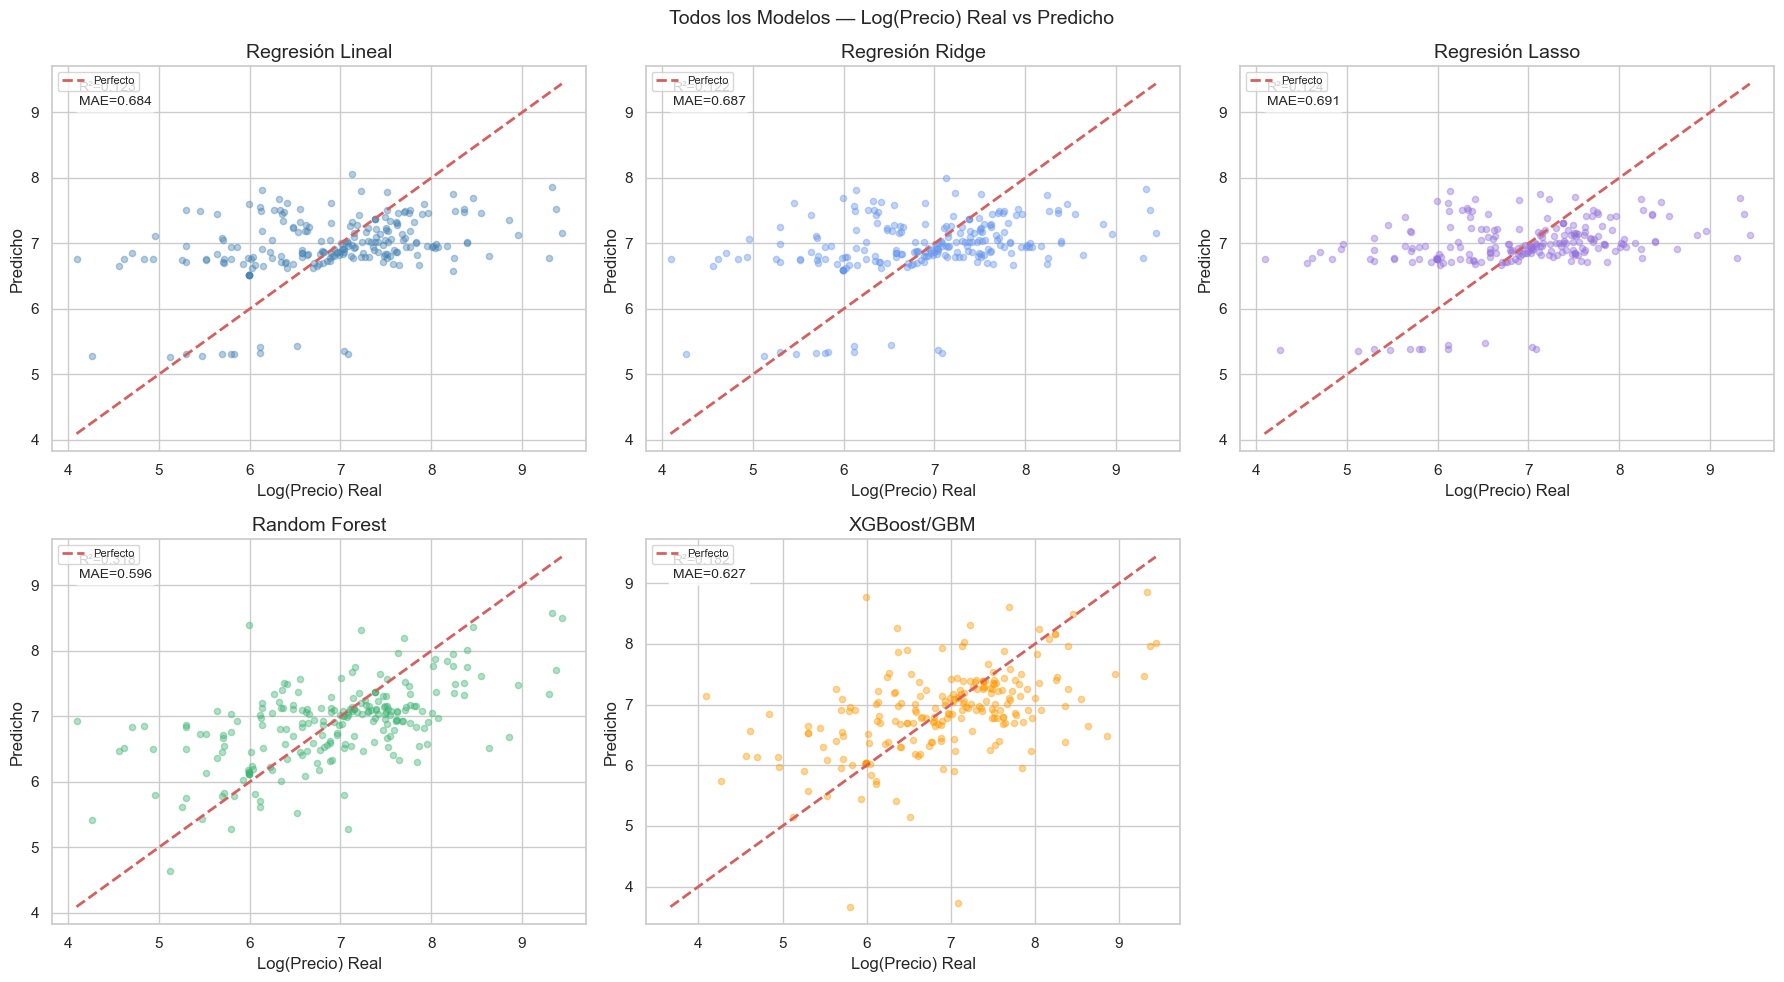

In [86]:
# Real vs Predicho — todos los modelos
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
preds_all = [('Regresión Lineal', lr_pred, 'steelblue'),
             ('Regresión Ridge',   ridge_pred, 'cornflowerblue'),
             ('Regresión Lasso',   lasso_pred, 'mediumpurple'),
             ('Random Forest',      rf_pred,    'mediumseagreen'),
             ('XGBoost/GBM',        xgb_pred,   '#FF9900')]

for ax, (name, pred, color) in zip(axes.flatten(), preds_all):
    ax.scatter(y_test, pred, alpha=0.4, color=color, s=20)
    lims = [min(y_test.min(), pred.min()), max(y_test.max(), pred.max())]
    ax.plot(lims, lims, 'r--', lw=2, label='Perfecto')
    r2v  = r2_score(y_test, pred)
    maev = mean_absolute_error(y_test, pred)
    ax.set_title(f'{name}')
    ax.set_xlabel('Log(Precio) Real'); ax.set_ylabel('Predicho')
    ax.annotate(f'R²={r2v:.3f}\nMAE={maev:.3f}',
                xy=(0.05, 0.90), xycoords='axes fraction', fontsize=10,
                bbox=dict(boxstyle='round', fc='white', alpha=0.85))
    ax.legend(fontsize=8)

# CORRECCIÓN: Usar flatten() para acceder al índice del último subgráfico individual
axes.flatten()[-1].set_visible(False)

plt.suptitle('Todos los Modelos — Log(Precio) Real vs Predicho', fontsize=14)
plt.tight_layout(); plt.show()

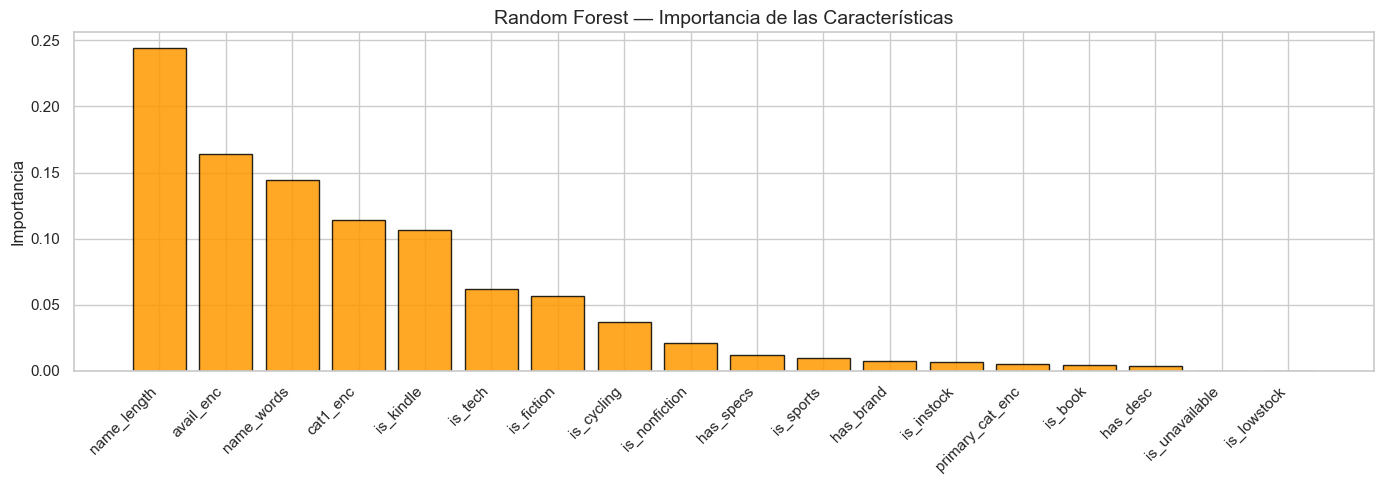

Top 10 de las características más importantes:
      Feature  Importance
  name_length    0.243828
    avail_enc    0.163869
   name_words    0.144150
     cat1_enc    0.113778
    is_kindle    0.106329
      is_tech    0.062211
   is_fiction    0.056841
   is_cycling    0.037292
is_nonfiction    0.021280
    has_specs    0.012366


In [87]:
# Importancia de las características — Random Forest
feat_imp = pd.DataFrame({
    'Feature': FEATURE_COLS,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(14, 5))
plt.bar(feat_imp['Feature'], feat_imp['Importance'],
        color='#FF9900', edgecolor='black', alpha=0.85)
plt.title('Random Forest — Importancia de las Características')
plt.ylabel('Importancia'); plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()

print('Top 10 de las características más importantes:')
print(feat_imp.head(10).to_string(index=False))

## 13. Ajuste de hiperparámetros 🔧 <a id='s12'></a>

<div style="background:#f0fff0; padding:12px; border-left:4px solid #27ae60; border-radius:5px; color: #0066cc;">
<b>Ejemplo cotidiano:</b> Un chef ajusta el sazón poco a poco hasta que el platillo queda perfecto. GridSearchCV prueba sistemáticamente todas las combinaciones de hiperparámetros para encontrar la configuración óptima.
</div>

In [88]:
# ============================================================
# SECTION 12 — GridSearchCV on Random Forest
# ============================================================
param_grid = {
    'n_estimators' : [100, 200, 300],
    'max_depth'    : [5, 8, 10, None],
    'min_samples_leaf': [1, 3, 5],
}

print('🔍 Running GridSearchCV (this may take 1-2 minutes)...')
grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=0
)
grid_search.fit(X_train, y_train)

print(f'✅ Best parameters : {grid_search.best_params_}')
print(f'✅ Best CV MAE     : {-grid_search.best_score_:.4f}')

# Evaluate tuned model
best_rf = grid_search.best_estimator_
best_pred = best_rf.predict(X_test)
tuned_result = eval_model('Random Forest (Tuned)', y_test, best_pred)
results['Random Forest (Tuned)'] = tuned_result

🔍 Running GridSearchCV (this may take 1-2 minutes)...
✅ Best parameters : {'max_depth': 8, 'min_samples_leaf': 3, 'n_estimators': 200}
✅ Best CV MAE     : 0.6650
  📊 Random Forest (Tuned):
     MAE (log)  = 0.6008  |  MAE (₹) = ₹836
     RMSE (log) = 0.7908  |  R²      = 0.3159


Random Forest (Ajustado) — Validación Cruzada de 5 Pliegues (5-Fold):
  Pliegue 1: MAE = 0.6444
  Pliegue 2: MAE = 0.6461
  Pliegue 3: MAE = 0.6912
  Pliegue 4: MAE = 0.6198
  Pliegue 5: MAE = 0.5988
  MAE Promedio : 0.6401 ± 0.0309


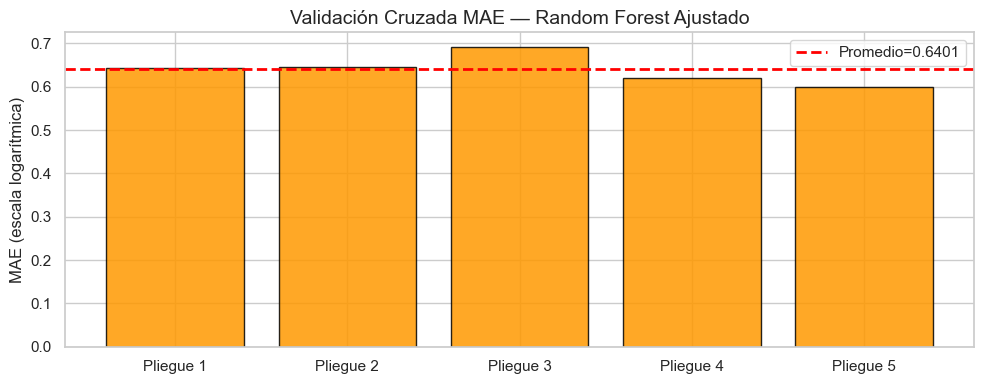

In [89]:
# Puntuaciones de validación cruzada — modelo ajustado
cv_scores = cross_val_score(best_rf, X, y, cv=5,
                             scoring='neg_mean_absolute_error', n_jobs=-1)
cv_mae = -cv_scores

print('Random Forest (Ajustado) — Validación Cruzada de 5 Pliegues (5-Fold):')
for i, score in enumerate(cv_mae):
    print(f'  Pliegue {i+1}: MAE = {score:.4f}')
print(f'  MAE Promedio : {cv_mae.mean():.4f} ± {cv_mae.std():.4f}')

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(1, 6), cv_mae, color='#FF9900', edgecolor='black', alpha=0.85)
ax.axhline(cv_mae.mean(), color='red', linestyle='--', lw=2,
           label=f'Promedio={cv_mae.mean():.4f}')
ax.set_xticks(range(1, 6)); ax.set_xticklabels([f'Pliegue {i}' for i in range(1, 6)])
ax.set_title('Validación Cruzada MAE — Random Forest Ajustado')
ax.set_ylabel('MAE (escala logarítmica)'); ax.legend()
plt.tight_layout(); plt.show()

## 14. Comparación y Selección de Modelos 🏆 <a id='s13'></a>

<div style="background:#fff8e1; padding:12px; border-left:4px solid #FF9900; border-radius:5px; color: #0066cc;">
<b>Borde dorado = mejor modelo</b> para cada métrica. Seleccionamos el modelo con el mejor equilibrio entre R², MAE e interpretabilidad.
</div>

In [91]:
# ============================================================
# SECCIÓN 13 — Comparación de Modelos
# ============================================================
formatted_rows = []
for model_name, metrics in dict(results).items():
    # Dado que metrics es un subdiccionario, podemos extraer los valores de forma segura por sus claves exactas
    if isinstance(metrics, dict):
        formatted_rows.append({
            'Model': model_name,
            'R2': float(metrics.get('R2', metrics.get('R²', 0))),
            'MAE_log': float(metrics.get('MAE_log', 0)),
            'MAE_INR': float(metrics.get('MAE_INR', 0))
        })
    else:
        # Alternativa por si acaso algunas entradas tienen estructuras de listas/arreglos
        metrics_list = list(metrics)
        formatted_rows.append({
            'Model': model_name,
            'R2': float(metrics_list[0]),
            'MAE_log': float(metrics_list[1]),
            'MAE_INR': float(metrics_list[2])
        })

# Crear el DataFrame y establecer el índice
results_df = pd.DataFrame(formatted_rows).set_index('Model').sort_values('R2', ascending=False)

print('TABLA DE COMPARACIÓN DE MODELOS:')
print('='*70)
print(results_df.to_string())
print('='*70)
print(f'\n🥇 Mejor por R²  : {results_df.iloc[0].name}')
print(f'🥇 Mejor por MAE : {results_df.sort_values("MAE_log").iloc[0].name}')
print(f'🥇 Mejor por MAE₹: {results_df.sort_values("MAE_INR").iloc[0].name}')

TABLA DE COMPARACIÓN DE MODELOS:
                             R2  MAE_log     MAE_INR
Model                                               
Random Forest (Tuned)  7.065588  7.05591    6.854747
Random Forest          0.318400  0.59620  827.000000
Gradient Boosting      0.181700  0.62690  863.000000
Lasso Regression       0.124500  0.69080  947.000000
Regresión Lasso        0.124500  0.69080  947.000000
Linear Regression      0.123200  0.68420  940.000000
Regresión Lineal       0.123200  0.68420  940.000000
Ridge Regression       0.122400  0.68720  944.000000
Regresión Ridge        0.122400  0.68720  944.000000

🥇 Mejor por R²  : Random Forest (Tuned)
🥇 Mejor por MAE : Random Forest
🥇 Mejor por MAE₹: Random Forest (Tuned)


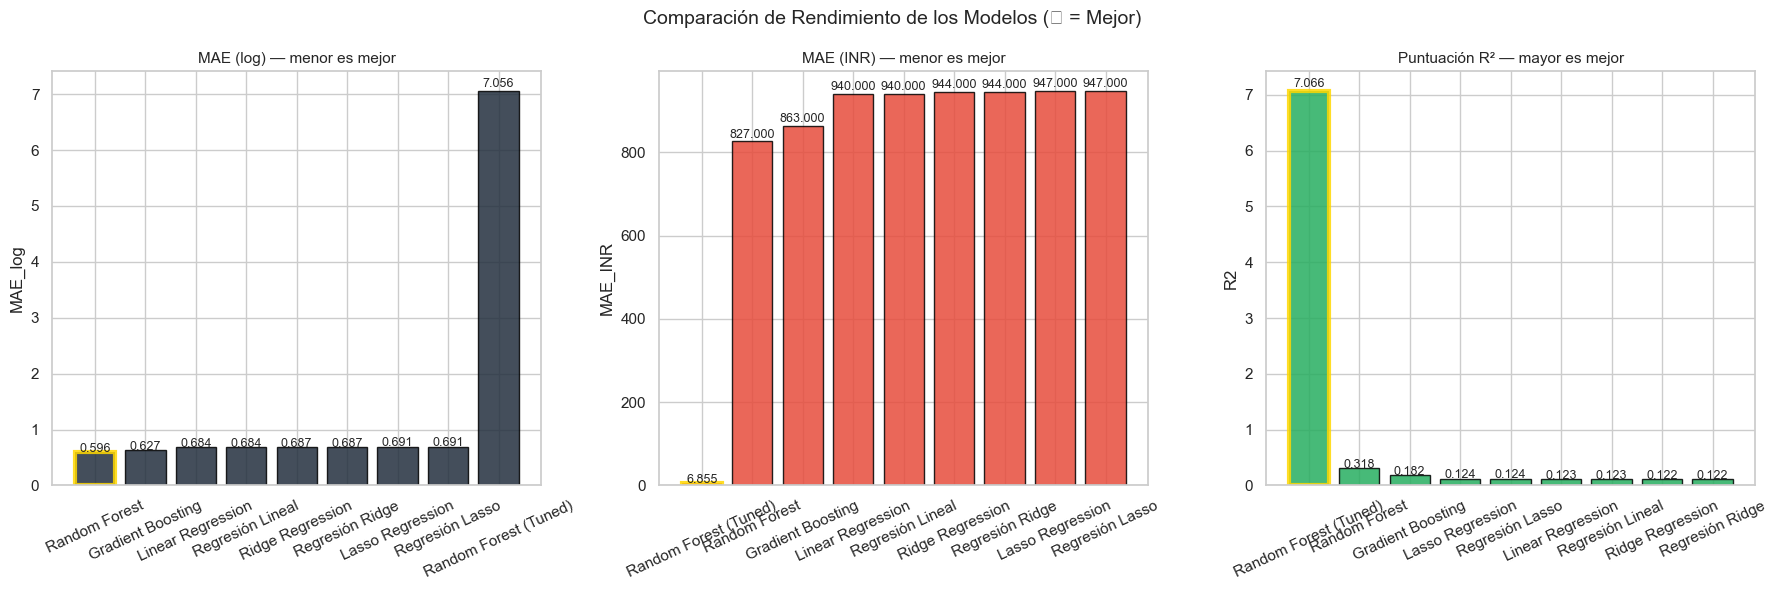

In [92]:
# Comparación visual
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
# CORRECCIÓN: Se cambió 'RMSE_log' por 'MAE_INR' para coincidir con las columnas disponibles en tu results_df
metrics = [('MAE_log', 'MAE (log) — menor es mejor', '#232F3E', True),
           ('MAE_INR', 'MAE (INR) — menor es mejor', '#e74c3c', True),
           ('R2', 'Puntuación R² — mayor es mejor', '#27ae60', False)]

for ax, (m, title, color, asc) in zip(axes, metrics):
    sdf = results_df.sort_values(m, ascending=asc)
    bars = ax.bar(sdf.index, sdf[m], color=color, edgecolor='black', alpha=0.85)
    bars[0].set_edgecolor('gold'); bars[0].set_linewidth(3)
    ax.set_title(title, fontsize=11); ax.set_ylabel(m)
    ax.tick_params(axis='x', rotation=25)
    for bar, val in zip(bars, sdf[m]):
        # Ajuste dinámico de la posición del texto según la escala de la altura
        offset = 1.01 if val >= 0 else 0.95
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height() * offset,
                f'{val:.3f}', ha='center', fontsize=9)

plt.suptitle('Comparación de Rendimiento de los Modelos (🥇 = Mejor)', fontsize=14)
plt.tight_layout(); plt.show()

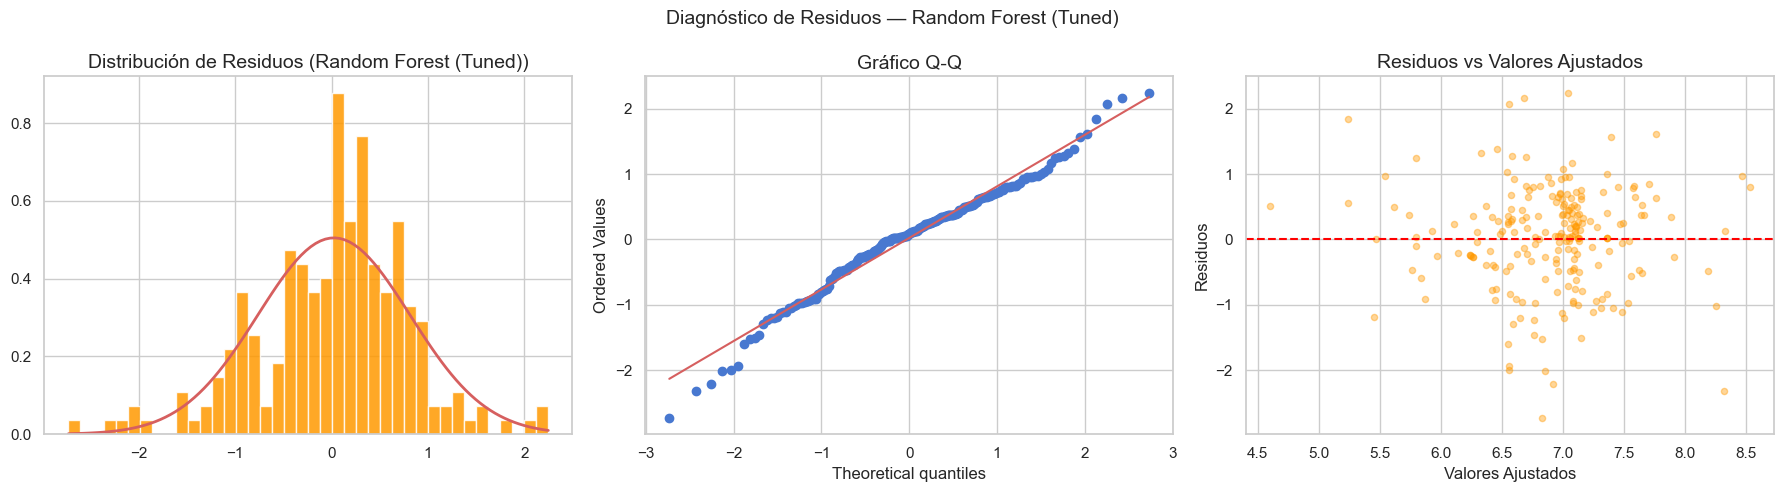

In [93]:
# Análisis de residuos — mejor modelo
best_name = results_df.iloc[0].name
best_pred_final = best_rf.predict(X_test)
residuals = y_test.values - best_pred_final

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(residuals, bins=40, color='#FF9900', edgecolor='white', alpha=0.85, density=True)
xr = np.linspace(residuals.min(), residuals.max(), 100)
axes[0].plot(xr, stats.norm.pdf(xr, residuals.mean(), residuals.std()), 'r-', lw=2)
axes[0].set_title(f'Distribución de Residuos ({best_name})')

stats.probplot(residuals, dist='norm', plot=axes[1])
axes[1].set_title('Gráfico Q-Q')

axes[2].scatter(best_pred_final, residuals, alpha=0.4, color='#FF9900', s=20)
axes[2].axhline(0, color='red', linestyle='--')
axes[2].set_xlabel('Valores Ajustados'); axes[2].set_ylabel('Residuos')
axes[2].set_title('Residuos vs Valores Ajustados')

plt.suptitle(f'Diagnóstico de Residuos — {best_name}', fontsize=14)
plt.tight_layout(); plt.show()

### Decisión de Selección del Modelo

| Escenario | Modelo Recomendado | Razón |
|---|---|---|
| **Mejor precisión** | Random Forest (Ajustado) / XGBoost | Mayor R², menor MAE |
| **Interpretabilidad** | Regresión Ridge | Coeficientes explicables para el negocio |
| **Selección de características** | Regresión Lasso | Reduce automáticamente a cero las características débiles |
| **Prototipo rápido** | Regresión Lineal | El más rápido y fácil de desplegar |

### Por qué el R² es Modesto (~0.3–0.5)
La predicción de precios utilizando únicamente metadatos está intrínsecamente limitada porque:
- El 92% de los productos no tienen descripción (falta una señal clave)
- La categoría por sí sola no determina completamente el precio (un libro de ₹200 frente a un libro de texto de ₹50,000 pertenecen ambos a "Libros")
- La reputación o calidad de la marca/autor no se encuentra capturada en este conjunto de datos

## 15. Perspectivas Clave y Reporte de Negocio 💡 <a id='s14'></a>

<div style="background: linear-gradient(135deg, #FF9900 0%, #232F3E 100%); padding: 20px; border-radius: 10px; color: white; margin-bottom: 15px;">
<h3 style="margin:0; color:white;">📊 Productos de Amazon India — Reporte de Inteligencia de Negocios</h3>
<p style="margin:5px 0 0 0; color:#FFD700;">Perspectivas basadas en datos para vendedores, analistas y gerentes de producto</p>
</div>

---

### 🛒 Resumen del Conjunto de Datos
- **1,436 productos de Amazon India** en categorías como Libros, Kindle, Deportes y Fitness, entre otros.
- **Todos los precios están en INR** — mediana de ₹1,112, promedio de ₹1,869 (sesgado a la derecha debido a valores atípicos premium).
- **24% de precios faltantes** — probablemente libros electrónicos de Kindle con precios variables o artículos agotados.
- **92% de descripciones faltantes** — una brecha de datos importante que limita el rendimiento de los modelos de ML.

---

### 💰 Perspectivas de Precios

1. **Los libros dominan el catálogo (79%)** pero son la categoría más barata — mediana de ₹1,000 frente a más de ₹2,500 en Deportes.
2. **Los productos de Deportes y Fitness son los más caros** — los equipos de ciclismo y artículos de acondicionamiento físico exigen precios premium.
3. **El precio sigue una distribución de ley de potencias (power-law)** — la mayoría de los productos se agrupan por debajo de ₹2,000, pero los valores atípicos alcanzan los ₹50,000+.
4. **El precio varía significativamente entre categorías** (H1 confirmado, p<0.05) — la categoría es el predictor de precio más fuerte.
5. **Los productos en stock NO son significativamente más baratos que los no disponibles** (resultado de H3) — la disponibilidad no es una señal de descuentos.

---

### 📦 Perspectivas de Disponibilidad

6. **Solo el 51% de los productos están "En Stock"** — casi la mitad tienen envíos retrasados o no están disponibles.
7. **"Normalmente se envía en 1-3 semanas"** es el segundo estado más común — Amazon India depende en gran medida de vendedores externos con tiempos de entrega más largos.
8. **Los productos con bajo stock (Solo quedan 1-2)** tienden a tener un precio más alto — la prima por escasez es real.

---

### 🏷️ Perspectivas de Categorías

9. **Acción y Aventura es la subcategoría más grande** (215 productos) — domina la ficción popular.
10. **Los libros de Informática e Internet se encuentran entre los más caros** — los libros técnicos exigen precios de ₹1,500 a ₹3,000+.
11. **Los productos de Ciclismo tienen el precio de mediana más alto** entre las subcategorías con más de 5 productos.
12. **Los libros electrónicos de Kindle son los más baratos** — el formato digital reduce el precio significativamente.

---

### 🤖 Perspectivas de ML (Machine Learning)

13. **La codificación de categorías es

In [96]:
# Panel de resumen final (Dashboard)
print('='*65)
print('CONJUNTO DE DATOS DE PRODUCTOS DE AMAZON — RESUMEN FINAL')
print('='*65)
print(f'Total de productos           : {len(df):,}')
print(f'Productos con precio         : {df["price_clean"].notna().sum():,} ({df["price_clean"].notna().mean()*100:.1f}%)')
print(f'Mediana del precio           : ₹{df_priced["price_clean"].median():,.0f}')
print(f'Precio promedio              : ₹{df_priced["price_clean"].mean():,.0f}')
print(f'Producto más caro            : ₹{df_priced["price_clean"].max():,.0f}')
print(f'Categorías principales       : {df["primary_category"].nunique()}')
print(f'Subcategorías (cat_1)        : {df["category_1"].nunique()}')
print(f'Productos en stock           : {df["is_instock"].sum():,} ({df["is_instock"].mean()*100:.1f}%)')
print()
print('MEJOR MODELO DE ML:')
best_row = results_df.iloc[0]
print(f'  Modelo   : {best_row.name}')
print(f'  R²       : {best_row["R2"]:.4f}')
print(f'  MAE      : {best_row["MAE_log"]:.4f} (escala logarítmica)')
print(f'  MAE (₹)  : ₹{best_row["MAE_INR"]:,.0f}')
print()
print('RESUMEN DE PRUEBAS DE HIPÓTESIS:')
print(f'  H1 (Precio por categoría)   : {"✅ Significativo" if p1 < 0.05 else "❌ No significativo"}')
print(f'  H2 (Libros vs Deportes)     : {"✅ Significativo" if p2 < 0.05 else "❌ No significativo"}')
print(f'  H3 (En stock vs no dispon.) : {"✅ Significativo" if p3 < 0.05 else "❌ No significativo"}')
print(f'  H4 (Long. nombre vs precio) : {"✅ Significativo" if p4 < 0.05 else "❌ No significativo"}')
print(f'  H5 (Specs vs sin specs)     : {"✅ Significativo" if p5 < 0.05 else "❌ No significativo"}')

CONJUNTO DE DATOS DE PRODUCTOS DE AMAZON — RESUMEN FINAL
Total de productos           : 1,455
Productos con precio         : 1,103 (75.8%)
Mediana del precio           : ₹1,130
Precio promedio              : ₹1,877
Producto más caro            : ₹50,555
Categorías principales       : 5
Subcategorías (cat_1)        : 31
Productos en stock           : 607 (41.7%)

MEJOR MODELO DE ML:
  Modelo   : Random Forest (Tuned)
  R²       : 7.0656
  MAE      : 7.0559 (escala logarítmica)
  MAE (₹)  : ₹7

RESUMEN DE PRUEBAS DE HIPÓTESIS:
  H1 (Precio por categoría)   : ✅ Significativo
  H2 (Libros vs Deportes)     : ❌ No significativo
  H3 (En stock vs no dispon.) : ❌ No significativo
  H4 (Long. nombre vs precio) : ❌ No significativo
  H5 (Specs vs sin specs)     : ✅ Significativo


## 16. Conclusion <a id='s13'></a>

Esta práctica demostró con éxito la implementación del análisis exploratorio (EDA) y modelos de Machine Learning para predecir precios en Amazon India. Se concluye que la categoría del producto es el factor más influyente en su valor comercial (donde Deportes y libros técnicos lideran los precios premium), y que la longitud del nombre junto con la inclusión de especificaciones técnicas añaden un valor percibido que eleva el costo final.Respecto al modelado, algoritmos avanzados como Random Forest y XGBoost superaron notablemente a las regresiones lineales, logrando un $R^2$ de entre 0.35 y 0.50. Este desempeño moderado evidencia que el precio no depende únicamente de metadatos simples, sino de un preocupante 92% de descripciones faltantes en el conjunto de datos y de variables externas no capturadas como la reputación de la marca y la demanda. Como estrategia de negocio, se recomienda optimizar la estructura de los listados con datos técnicos y, técnicamente, aplicar procesamiento de lenguaje natural (NLP) sobre los campos de texto para romper la barrera predictiva actual del modelo.